<a href="https://www.kaggle.com/code/lalit7881/steam-games-dataset-v2-eda-83-75?scriptVersionId=342959235" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/muhammadaqeelkabir/steam-games-dataset-v2/extended_steam_games.csv
/kaggle/input/datasets/muhammadaqeelkabir/steam-games-dataset-v2/steam_games_wikidata.csv
/kaggle/input/datasets/muhammadaqeelkabir/steam-games-dataset-v2/steamspy_raw.csv


## Loading dataset

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 100)

# ============================================================
# 2. DATASET PATHS
# ============================================================

extended_path = "/kaggle/input/datasets/muhammadaqeelkabir/steam-games-dataset-v2/extended_steam_games.csv"
wikidata_path = "/kaggle/input/datasets/muhammadaqeelkabir/steam-games-dataset-v2/steam_games_wikidata.csv"
steamspy_path = "/kaggle/input/datasets/muhammadaqeelkabir/steam-games-dataset-v2/steamspy_raw.csv"

# ============================================================
# 3. LOAD DATASETS
# ============================================================

df_extended = pd.read_csv(extended_path)
df_wikidata = pd.read_csv(wikidata_path)
df_steamspy = pd.read_csv(steamspy_path)

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [3]:
print("=" * 70)
print("DATASET SHAPES")
print("=" * 70)

print("Extended Steam Games :", df_extended.shape)
print("Steam Games Wikidata:", df_wikidata.shape)
print("SteamSpy Raw        :", df_steamspy.shape)

DATASET SHAPES
Extended Steam Games : (23100, 28)
Steam Games Wikidata: (128348, 8)
SteamSpy Raw        : (30000, 15)


In [4]:
print("\n" + "=" * 70)
print("EXTENDED STEAM GAMES")
print("=" * 70)

display(df_extended.head())

print("\n" + "=" * 70)
print("WIKIDATA")
print("=" * 70)

display(df_wikidata.head())

print("\n" + "=" * 70)
print("STEAMSPY")
print("=" * 70)

display(df_steamspy.head())


EXTENDED STEAM GAMES


,appid,name,developer,publisher,positive,negative,owners,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu,release_date,required_age,is_free,short_description,supported_languages,platforms_windows,platforms_mac,platforms_linux,metacritic_score,recommendations,achievements,genres,categories
0,730,Counter-Strike: Global Offensive,Valve,Valve,7642084,1173003,"100,000,000 .. 200,000,000",0,0,0,0,0,0,0,1013936,"21 Aug, 2012",0.0,True,"For over two decades, Counter-Strike has offered an elite competitive experience, one shaped by ...","Czech, Danish, Dutch, English<strong>*</strong>, Finnish, French, German, Hungarian, Italian, Ja...",True,False,True,NaN,5211693.0,1.0,"Action, Free To Play","Multi-player, Cross-Platform Multiplayer, Steam Trading Cards, Steam Workshop, Steam Workshop, I..."
1,1172470,Apex Legends,Respawn,Electronic Arts,668053,326926,"100,000,000 .. 200,000,000",0,0,0,0,0,0,0,124262,"4 Nov, 2020",0.0,True,"Apex Legends is the award-winning, free-to-play Hero Shooter from Respawn Entertainment. Master ...","English<strong>*</strong>, French<strong>*</strong>, Italian<strong>*</strong>, German<strong>*<...",True,False,False,88.0,1580.0,12.0,"Action, Adventure, Free To Play","Multi-player, PvP, Online PvP, Co-op, Online Co-op, Steam Achievements, Full controller support,..."
2,578080,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.",1520457,1037487,"100,000,000 .. 200,000,000",0,0,0,0,0,0,0,314682,"21 Dec, 2017",19.0,True,"PUBG: BATTLEGROUNDS, the high-stakes winner-take-all shooter that started the Battle Royale craz...","English, Korean, Simplified Chinese, French, German, Spanish - Spain, Arabic, Japanese, Polish, ...",True,False,False,NaN,1762488.0,37.0,"Action, Adventure, Massively Multiplayer, Free To Play","Multi-player, PvP, Online PvP, Custom Volume Controls, Stereo Sound, Surround Sound, Partial Con..."
3,1623730,Palworld,Pocketpair,Pocketpair,358266,22443,"50,000,000 .. 100,000,000",0,0,0,0,2999,2999,0,18028,"Jul 9, 2026",0.0,False,"Fight, farm, build and work alongside mysterious creatures called &quot;Pals&quot; in this compl...","English, Simplified Chinese, Traditional Chinese, Japanese, French, Italian, German, Spanish - S...",True,False,False,NaN,397504.0,75.0,"Action, Adventure, Indie, RPG","Single-player, Multi-player, Co-op, Online Co-op, Cross-Platform Multiplayer, Steam Achievements..."
4,440,Team Fortress 2,Valve,Valve,1044264,117208,"50,000,000 .. 100,000,000",0,0,0,0,0,0,0,43819,"10 Oct, 2007",0.0,True,Nine distinct classes provide a broad range of tactical abilities and personalities. Constantly ...,"English<strong>*</strong>, Danish, Dutch, Finnish, French, German, Italian, Japanese, Norwegian,...",True,False,True,92.0,47647.0,520.0,"Action, Free To Play","Multi-player, Cross-Platform Multiplayer, Steam Achievements, Steam Trading Cards, Captions avai..."



WIKIDATA


,appid,wikidata_name,esrb_rating,hltb_id,igdb_id,metacritic_id,opencritic_id,game_engine
0,17080,Tribes: Ascend,Teen,NaN,tribes-ascend,NaN,NaN,Unreal Engine 3
1,24790,Command & Conquer 3: Tiberium Wars,Teen,NaN,command-conquer-3-tiberium-wars,NaN,NaN,SAGE
2,2290,Q1088780,Mature 17+,NaN,final-doom,NaN,NaN,id Tech 1
3,20,Team Fortress Classic,Mature 17+,NaN,team-fortress-classic,NaN,NaN,GoldSrc
4,203750,Binary Domain,Mature 17+,NaN,binary-domain,NaN,12631.0,NaN



STEAMSPY


,appid,name,developer,publisher,positive,negative,owners,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu
0,730,Counter-Strike: Global Offensive,Valve,Valve,7642084,1173003,"100,000,000 .. 200,000,000",0,0,0,0,0,0,0,1013936
1,1172470,Apex Legends,Respawn,Electronic Arts,668053,326926,"100,000,000 .. 200,000,000",0,0,0,0,0,0,0,124262
2,578080,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.",1520457,1037487,"100,000,000 .. 200,000,000",0,0,0,0,0,0,0,314682
3,1623730,Palworld,Pocketpair,Pocketpair,358266,22443,"50,000,000 .. 100,000,000",0,0,0,0,2999,2999,0,18028
4,440,Team Fortress 2,Valve,Valve,1044264,117208,"50,000,000 .. 100,000,000",0,0,0,0,0,0,0,43819


In [5]:
display(df_extended.tail())
display(df_wikidata.tail())
display(df_steamspy.tail())

,appid,name,developer,publisher,positive,negative,owners,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu,release_date,required_age,is_free,short_description,supported_languages,platforms_windows,platforms_mac,platforms_linux,metacritic_score,recommendations,achievements,genres,categories
23095,1360040,uVolley,Nick,IElectric,36,32,"20,000 .. 50,000",0,0,0,0,0,0,0,0,"24 Jul, 2020",0.0,True,"A new vision of the volleyball video game developed by a volleyball player, play a match or leag...","English<strong>*</strong>, French, Italian, German, Portuguese - Brazil, Russian, Thai<br><stron...",True,False,False,NaN,0.0,15.0,"Indie, Sports","Single-player, Multi-player, PvP, Online PvP, LAN PvP, Shared/Split Screen PvP, Co-op, Online Co..."
23096,851880,RŌA,ARQUOIA,ARQUOIA,11,9,"20,000 .. 50,000",0,0,0,0,299,299,0,0,"Jun 2, 2018",0.0,False,Chasing colors in the void. A game we made to Zen you.,"English, French, Italian, German, Spanish - Spain, Arabic, Portuguese - Brazil, Bulgarian, Tradi...",True,False,False,NaN,0.0,3.0,"Adventure, Indie","Single-player, Steam Achievements, Full controller support, Family Sharing"
23097,1693620,The Vaults of Minos,Thunder Perfect Witchcraft,Thunder Perfect Witchcraft,2,0,"20,000 .. 50,000",0,0,0,0,400,400,0,0,"29 Aug, 2022",0.0,True,The Vaults of Minos is a fluid arcade Jump 'n Run with a gripping story and randomized levels. E...,English<strong>*</strong><br><strong>*</strong>languages with full audio support,True,False,True,NaN,0.0,24.0,"Action, Adventure, Casual, Indie, Free To Play","Single-player, Steam Achievements, Full controller support, Family Sharing"
23098,1453280,MEIRIN IN FISTS OF FIRE,青春18金魚,青春18金魚,11,0,"20,000 .. 50,000",0,0,0,0,399,399,0,0,"3 Dec, 2020",0.0,False,90's style super real battle action where live-action men fight in cosplay. A big character narr...,"English, Japanese",True,False,False,NaN,0.0,0.0,"Action, Indie","Single-player, Multi-player, PvP, Shared/Split Screen PvP, Shared/Split Screen, Partial Controll..."
23099,1559850,Space Survival,Ali Soltanian Fard Jahromi,Soltanian Games,11,4,"20,000 .. 50,000",0,0,0,0,0,0,0,0,"Mar 10, 2021",0.0,True,Space Survival is a 3D PC shoote'm up game with large maps and various levels to complete.,English<strong>*</strong><br><strong>*</strong>languages with full audio support,True,False,False,NaN,0.0,0.0,"Action, Adventure, Free To Play","Single-player, Family Sharing"


,appid,wikidata_name,esrb_rating,hltb_id,igdb_id,metacritic_id,opencritic_id,game_engine
128343,3299300,Q140096147,NaN,NaN,magicians-the-devils-deal,NaN,NaN,NaN
128344,4009730,Feed the Reactor,NaN,NaN,NaN,NaN,NaN,NaN
128345,4406790,Imperial Kingdoms,NaN,NaN,NaN,NaN,NaN,NaN
128346,4580800,Q140506066,NaN,NaN,NaN,NaN,NaN,NaN
128347,2218560,PixiEditor,NaN,NaN,NaN,NaN,NaN,NaN


,appid,name,developer,publisher,positive,negative,owners,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu
29995,2212520,The Last Werewolf,Unnatural Freaks,Unnatural Freaks,10,0,"0 .. 20,000",0,0,0,0,699,699,0,0
29996,1699280,Hammerheart,Hammerheart,Hammerheart,34,14,"0 .. 20,000",0,0,0,0,1099,1099,0,0
29997,2556090,Rhino Puzzle,"Tero Lunkka, Valkeala Software",Tero Lunkka,8,2,"0 .. 20,000",0,0,0,0,499,499,0,0
29998,2341300,Car Delivery Man,Skulfio,Skulfio,3,0,"0 .. 20,000",0,0,0,0,99,99,0,0
29999,1083850,Fantasy Hero Manager,Mykel Flynn,Mykel Flynn,7,14,"0 .. 20,000",0,0,0,0,699,699,0,0


In [6]:
print("Extended Steam Games Columns:")
print(df_extended.columns.tolist())

print("\nWikidata Columns:")
print(df_wikidata.columns.tolist())

print("\nSteamSpy Columns:")
print(df_steamspy.columns.tolist())

Extended Steam Games Columns:
['appid', 'name', 'developer', 'publisher', 'positive', 'negative', 'owners', 'average_forever', 'average_2weeks', 'median_forever', 'median_2weeks', 'price', 'initialprice', 'discount', 'ccu', 'release_date', 'required_age', 'is_free', 'short_description', 'supported_languages', 'platforms_windows', 'platforms_mac', 'platforms_linux', 'metacritic_score', 'recommendations', 'achievements', 'genres', 'categories']

Wikidata Columns:
['appid', 'wikidata_name', 'esrb_rating', 'hltb_id', 'igdb_id', 'metacritic_id', 'opencritic_id', 'game_engine']

SteamSpy Columns:
['appid', 'name', 'developer', 'publisher', 'positive', 'negative', 'owners', 'average_forever', 'average_2weeks', 'median_forever', 'median_2weeks', 'price', 'initialprice', 'discount', 'ccu']


In [7]:
print("Extended columns :", len(df_extended.columns))
print("Wikidata columns :", len(df_wikidata.columns))
print("SteamSpy columns :", len(df_steamspy.columns))

Extended columns : 28
Wikidata columns : 8
SteamSpy columns : 15


In [8]:
print("=" * 70)
print("EXTENDED DATASET INFO")
print("=" * 70)

df_extended.info()

print("\n" + "=" * 70)
print("WIKIDATA INFO")
print("=" * 70)

df_wikidata.info()

print("\n" + "=" * 70)
print("STEAMSPY INFO")
print("=" * 70)

df_steamspy.info()

EXTENDED DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23100 entries, 0 to 23099
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   appid                23100 non-null  int64  
 1   name                 23099 non-null  object 
 2   developer            23034 non-null  object 
 3   publisher            22967 non-null  object 
 4   positive             23100 non-null  int64  
 5   negative             23100 non-null  int64  
 6   owners               23100 non-null  object 
 7   average_forever      23100 non-null  int64  
 8   average_2weeks       23100 non-null  int64  
 9   median_forever       23100 non-null  int64  
 10  median_2weeks        23100 non-null  int64  
 11  price                23100 non-null  int64  
 12  initialprice         23100 non-null  int64  
 13  discount             23100 non-null  int64  
 14  ccu                  23100 non-null  int64  
 15  release_date  

In [9]:
print("Extended Data Types")
display(df_extended.dtypes.to_frame("Data Type"))

print("Wikidata Data Types")
display(df_wikidata.dtypes.to_frame("Data Type"))

print("SteamSpy Data Types")
display(df_steamspy.dtypes.to_frame("Data Type"))

Extended Data Types


,Data Type
appid,int64
name,object
developer,object
publisher,object
positive,int64
negative,int64
owners,object
average_forever,int64
average_2weeks,int64
median_forever,int64


Wikidata Data Types


,Data Type
appid,int64
wikidata_name,object
esrb_rating,object
hltb_id,float64
igdb_id,object
metacritic_id,float64
opencritic_id,float64
game_engine,object


SteamSpy Data Types


,Data Type
appid,int64
name,object
developer,object
publisher,object
positive,int64
negative,int64
owners,object
average_forever,int64
average_2weeks,int64
median_forever,int64


In [10]:
def column_summary(df, name):
    numerical = df.select_dtypes(include=np.number).columns.tolist()
    categorical = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print("\nNumerical Columns:")
    print(numerical)

    print("\nCategorical/Object Columns:")
    print(categorical)

    print("\nNumber of Numerical Columns:", len(numerical))
    print("Number of Categorical Columns:", len(categorical))


column_summary(df_extended, "EXTENDED STEAM GAMES")
column_summary(df_wikidata, "WIKIDATA")
column_summary(df_steamspy, "STEAMSPY")


EXTENDED STEAM GAMES

Numerical Columns:
['appid', 'positive', 'negative', 'average_forever', 'average_2weeks', 'median_forever', 'median_2weeks', 'price', 'initialprice', 'discount', 'ccu', 'required_age', 'metacritic_score', 'recommendations', 'achievements']

Categorical/Object Columns:
['name', 'developer', 'publisher', 'owners', 'release_date', 'is_free', 'short_description', 'supported_languages', 'platforms_windows', 'platforms_mac', 'platforms_linux', 'genres', 'categories']

Number of Numerical Columns: 15
Number of Categorical Columns: 13

WIKIDATA

Numerical Columns:
['appid', 'hltb_id', 'metacritic_id', 'opencritic_id']

Categorical/Object Columns:
['wikidata_name', 'esrb_rating', 'igdb_id', 'game_engine']

Number of Numerical Columns: 4
Number of Categorical Columns: 4

STEAMSPY

Numerical Columns:
['appid', 'positive', 'negative', 'average_forever', 'average_2weeks', 'median_forever', 'median_2weeks', 'price', 'initialprice', 'discount', 'ccu']

Categorical/Object Column

In [11]:
def missing_value_analysis(df, name):

    missing = df.isnull().sum()
    missing_percent = (missing / len(df)) * 100

    result = pd.DataFrame({
        "Missing Values": missing,
        "Missing Percentage": missing_percent
    })

    result = result.sort_values(
        by="Missing Percentage",
        ascending=False
    )

    print("\n" + "=" * 70)
    print(name, "- MISSING VALUES")
    print("=" * 70)

    display(result)


missing_value_analysis(df_extended, "EXTENDED")
missing_value_analysis(df_wikidata, "WIKIDATA")
missing_value_analysis(df_steamspy, "STEAMSPY")


EXTENDED - MISSING VALUES


,Missing Values,Missing Percentage
metacritic_score,19394,83.956710
categories,148,0.640693
publisher,133,0.575758
genres,109,0.471861
release_date,102,0.441558
short_description,67,0.290043
developer,66,0.285714
supported_languages,63,0.272727
is_free,48,0.207792
required_age,48,0.207792



WIKIDATA - MISSING VALUES


,Missing Values,Missing Percentage
metacritic_id,128348,100.000000
hltb_id,128347,99.999221
esrb_rating,121836,94.926294
game_engine,117846,91.817559
opencritic_id,115096,89.674946
igdb_id,11603,9.040266
wikidata_name,1,0.000779
appid,0,0.000000



STEAMSPY - MISSING VALUES


,Missing Values,Missing Percentage
publisher,186,0.620000
developer,86,0.286667
name,1,0.003333
appid,0,0.000000
positive,0,0.000000
negative,0,0.000000
owners,0,0.000000
average_forever,0,0.000000
average_2weeks,0,0.000000
median_forever,0,0.000000


In [12]:
def missing_columns(df):
    return df.columns[df.isnull().any()].tolist()

print("Extended:")
print(missing_columns(df_extended))

print("\nWikidata:")
print(missing_columns(df_wikidata))

print("\nSteamSpy:")
print(missing_columns(df_steamspy))

Extended:
['name', 'developer', 'publisher', 'release_date', 'required_age', 'is_free', 'short_description', 'supported_languages', 'platforms_windows', 'platforms_mac', 'platforms_linux', 'metacritic_score', 'recommendations', 'achievements', 'genres', 'categories']

Wikidata:
['wikidata_name', 'esrb_rating', 'hltb_id', 'igdb_id', 'metacritic_id', 'opencritic_id', 'game_engine']

SteamSpy:
['name', 'developer', 'publisher']


In [13]:
print("Extended total missing:", df_extended.isnull().sum().sum())
print("Wikidata total missing :", df_wikidata.isnull().sum().sum())
print("SteamSpy total missing :", df_steamspy.isnull().sum().sum())

Extended total missing: 20419
Wikidata total missing : 623077
SteamSpy total missing : 273


In [14]:
def duplicate_analysis(df, name):

    duplicates = df.duplicated().sum()

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print("Duplicate Rows:", duplicates)

    if duplicates > 0:
        display(df[df.duplicated(keep=False)].head(20))


duplicate_analysis(df_extended, "EXTENDED")
duplicate_analysis(df_wikidata, "WIKIDATA")
duplicate_analysis(df_steamspy, "STEAMSPY")


EXTENDED
Duplicate Rows: 489


,appid,name,developer,publisher,positive,negative,owners,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu,release_date,required_age,is_free,short_description,supported_languages,platforms_windows,platforms_mac,platforms_linux,metacritic_score,recommendations,achievements,genres,categories
2998,214870,Painkiller Hell & Damnation,The Farm 51,Prime Matter,3258,919,"200,000 .. 500,000",0,0,0,0,199,1999,90,4,"Oct 31, 2012",0.0,False,"Evil has returned! Demonic powers are manifesting themselves as a myriad of dark creatures, figh...","English<strong>*</strong>, German<strong>*</strong>, French<strong>*</strong>, Italian<strong>*<...",True,True,True,64.0,2928.0,107.0,Action,"Single-player, Multi-player, Co-op, Shared/Split Screen, Steam Achievements, Steam Trading Cards..."
2999,471550,Nine Parchments,Frozenbyte,Frozenbyte,3427,997,"200,000 .. 500,000",0,0,0,0,1999,1999,0,18,"Dec 5, 2017",0.0,False,"Nine Parchments is a co-operative blast'em up game of magic mayhem from Frozenbyte, creators of ...","English<strong>*</strong>, French, Italian, German, Spanish - Spain, Japanese, Russian, Simplifi...",True,False,False,NaN,4102.0,54.0,"Action, RPG","Single-player, Multi-player, PvP, Online PvP, Shared/Split Screen PvP, Co-op, Online Co-op, Shar..."
3001,471550,Nine Parchments,Frozenbyte,Frozenbyte,3427,997,"200,000 .. 500,000",0,0,0,0,1999,1999,0,18,"Dec 5, 2017",0.0,False,"Nine Parchments is a co-operative blast'em up game of magic mayhem from Frozenbyte, creators of ...","English<strong>*</strong>, French, Italian, German, Spanish - Spain, Japanese, Russian, Simplifi...",True,False,False,NaN,4102.0,54.0,"Action, RPG","Single-player, Multi-player, PvP, Online PvP, Shared/Split Screen PvP, Co-op, Online Co-op, Shar..."
3003,214870,Painkiller Hell & Damnation,The Farm 51,Prime Matter,3258,919,"200,000 .. 500,000",0,0,0,0,199,1999,90,4,"Oct 31, 2012",0.0,False,"Evil has returned! Demonic powers are manifesting themselves as a myriad of dark creatures, figh...","English<strong>*</strong>, German<strong>*</strong>, French<strong>*</strong>, Italian<strong>*<...",True,True,True,64.0,2928.0,107.0,Action,"Single-player, Multi-player, Co-op, Shared/Split Screen, Steam Achievements, Steam Trading Cards..."
3989,270170,Depression Quest,"The Quinnspiracy, Patrick Lindsey, Isaac Schankler",The Quinnspiracy,2387,1587,"200,000 .. 500,000",0,0,0,0,0,0,0,2,"Aug 11, 2014",0.0,True,Depression Quest is an interactive fiction game where you play as someone living with depression...,English<strong>*</strong><br><strong>*</strong>languages with full audio support,True,True,True,NaN,0.0,0.0,"Free To Play, Indie, RPG, Simulation","Single-player, Full controller support, Family Sharing"
3997,394870,Office Battle,Black Lime Studio,Black Lime Studio,707,240,"200,000 .. 500,000",0,0,0,0,99,99,0,0,"Dec 2, 2015",0.0,False,Welcome to Office Battle! Many workers will lose their job because a layoff is happening very so...,"English<strong>*</strong>, Russian<br><strong>*</strong>languages with full audio support",True,False,False,NaN,837.0,15.0,"Violent, Action, Indie","Single-player, Steam Achievements, Steam Trading Cards, Steam Cloud, Steam Leaderboards, Include..."
4000,270170,Depression Quest,"The Quinnspiracy, Patrick Lindsey, Isaac Schankler",The Quinnspiracy,2387,1587,"200,000 .. 500,000",0,0,0,0,0,0,0,2,"Aug 11, 2014",0.0,True,Depression Quest is an interactive fiction game where you play as someone living with depression...,English<strong>*</strong><br><strong>*</strong>languages with full audio support,True,True,True,NaN,0.0,0.0,"Free To Play, Indie, RPG, Simulation","Single-player, Full controller support, Family Sharing"
4001,394870,Office Battle,Black Lime Studio,Black Lime Studio,707,240,"200,000 .. 500,000",0,0,0,0,99,99,0,0,"Dec 2, 2015",0.0,False,Welcome to Office Battle! Many workers will lose their job because a layoff is happening very so...,"English<strong>*</strong>, Russian<br><strong>*</strong>languages


WIKIDATA
Duplicate Rows: 0

STEAMSPY
Duplicate Rows: 1166


,appid,name,developer,publisher,positive,negative,owners,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu
2998,214870,Painkiller Hell & Damnation,The Farm 51,Prime Matter,3258,919,"200,000 .. 500,000",0,0,0,0,199,1999,90,4
2999,471550,Nine Parchments,Frozenbyte,Frozenbyte,3427,997,"200,000 .. 500,000",0,0,0,0,1999,1999,0,18
3001,471550,Nine Parchments,Frozenbyte,Frozenbyte,3427,997,"200,000 .. 500,000",0,0,0,0,1999,1999,0,18
3003,214870,Painkiller Hell & Damnation,The Farm 51,Prime Matter,3258,919,"200,000 .. 500,000",0,0,0,0,199,1999,90,4
3989,270170,Depression Quest,"The Quinnspiracy, Patrick Lindsey, Isaac Schankler",The Quinnspiracy,2387,1587,"200,000 .. 500,000",0,0,0,0,0,0,0,2
3997,394870,Office Battle,Black Lime Studio,Black Lime Studio,707,240,"200,000 .. 500,000",0,0,0,0,99,99,0,0
4000,270170,Depression Quest,"The Quinnspiracy, Patrick Lindsey, Isaac Schankler",The Quinnspiracy,2387,1587,"200,000 .. 500,000",0,0,0,0,0,0,0,2
4001,394870,Office Battle,Black Lime Studio,Black Lime Studio,707,240,"200,000 .. 500,000",0,0,0,0,99,99,0,0
4990,2478970,Tomb Raider I-III Remastered Starring Lara Croft,"Aspyr, Crystal Dynamics",Aspyr,6128,721,"200,000 .. 500,000",0,0,0,0,2999,2999,0,252
4991,3185510,Lucky Pikinini - Advanced Killer Cyborg,Lucky Pikinini,Lucky Pikinini,2,1,"200,000 .. 500,000",0,0,0,0,99,199,50,0


In [15]:
print("EXTENDED DATASET STATISTICS")
display(df_extended.describe().T)

print("WIKIDATA STATISTICS")
display(df_wikidata.describe().T)

print("STEAMSPY STATISTICS")
display(df_steamspy.describe().T)

EXTENDED DATASET STATISTICS


,count,mean,std,min,25%,50%,75%,max
appid,23100.0,1.105210e+06,799863.877084,10.0,433315.00,927555.0,1591632.5,3738180.0
positive,23100.0,5.401016e+03,63023.259201,0.0,49.00,286.0,1304.0,7642084.0
negative,23100.0,8.785115e+02,11964.986824,0.0,15.00,75.0,264.0,1173003.0
average_forever,23100.0,0.000000e+00,0.000000,0.0,0.00,0.0,0.0,0.0
average_2weeks,23100.0,0.000000e+00,0.000000,0.0,0.00,0.0,0.0,0.0
median_forever,23100.0,0.000000e+00,0.000000,0.0,0.00,0.0,0.0,0.0
median_2weeks,23100.0,0.000000e+00,0.000000,0.0,0.00,0.0,0.0,0.0
price,23100.0,9.045184e+02,1066.360068,0.0,99.00,499.0,1399.0,19999.0
initialprice,23100.0,1.012827e+03,1150.405539,0.0,124.75,699.0,1499.0,19999.0
discount,23100.0,6.293723e+00,20.240951,0.0,0.00,0.0,0.0,100.0


WIKIDATA STATISTICS


,count,mean,std,min,25%,50%,75%,max
appid,128348.0,1.899603e+06,1.002454e+06,1.000000e+01,1.055452e+06,1.858080e+06,2.729355e+06,5.005310e+06
hltb_id,1.0,1.455518e+09,NaN,1.455518e+09,1.455518e+09,1.455518e+09,1.455518e+09,1.455518e+09
metacritic_id,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
opencritic_id,13252.0,1.133594e+04,5.825243e+03,1.500000e+01,6.330750e+03,1.185950e+04,1.640225e+04,2.089700e+04


STEAMSPY STATISTICS


,count,mean,std,min,25%,50%,75%,max
appid,30000.0,1.178795e+06,814968.920292,10.0,489335.0,1033755.0,1693265.00,3738180.0
positive,30000.0,4.181105e+03,55347.496031,0.0,25.0,162.0,798.25,7642084.0
negative,30000.0,6.821180e+02,10505.352500,0.0,7.0,44.0,176.00,1173003.0
average_forever,30000.0,0.000000e+00,0.000000,0.0,0.0,0.0,0.00,0.0
average_2weeks,30000.0,0.000000e+00,0.000000,0.0,0.0,0.0,0.00,0.0
median_forever,30000.0,0.000000e+00,0.000000,0.0,0.0,0.0,0.00,0.0
median_2weeks,30000.0,0.000000e+00,0.000000,0.0,0.0,0.0,0.00,0.0
price,30000.0,8.502295e+02,1008.643477,0.0,99.0,499.0,1199.00,19999.0
initialprice,30000.0,9.455468e+02,1086.813005,0.0,199.0,599.0,1499.00,19999.0
discount,30000.0,5.861800e+00,19.513508,0.0,0.0,0.0,0.00,100.0


In [16]:
print("EXTENDED DATASET")
display(df_extended.describe(include="all").T)

print("WIKIDATA")
display(df_wikidata.describe(include="all").T)

print("STEAMSPY")
display(df_steamspy.describe(include="all").T)

EXTENDED DATASET


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
appid,23100.0,NaN,NaN,NaN,1105209.576147,799863.877084,10.0,433315.0,927555.0,1591632.5,3738180.0
name,23099,22541,F.E.A.R.,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
developer,23034,15155,"KOEI TECMO GAMES CO., LTD.",69,NaN,NaN,NaN,NaN,NaN,NaN,NaN
publisher,22967,12060,Ubisoft,135,NaN,NaN,NaN,NaN,NaN,NaN,NaN
positive,23100.0,NaN,NaN,NaN,5401.015671,63023.259201,0.0,49.0,286.0,1304.0,7642084.0
negative,23100.0,NaN,NaN,NaN,878.511515,11964.986824,0.0,15.0,75.0,264.0,1173003.0
owners,23100,12,"20,000 .. 50,000",8067,NaN,NaN,NaN,NaN,NaN,NaN,NaN
average_forever,23100.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
average_2weeks,23100.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
median_forever,23100.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0


WIKIDATA


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
appid,128348.0,NaN,NaN,NaN,1899603.266923,1002454.288395,10.0,1055452.5,1858080.0,2729355.0,5005310.0
wikidata_name,128347,127135,Labyrinth,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
esrb_rating,6512,12,Teen,2142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hltb_id,1.0,NaN,NaN,NaN,1455517844.0,NaN,1455517844.0,1455517844.0,1455517844.0,1455517844.0,1455517844.0
igdb_id,116745,116541,girls-frontline,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
metacritic_id,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
opencritic_id,13252.0,NaN,NaN,NaN,11335.94099,5825.24285,15.0,6330.75,11859.5,16402.25,20897.0
game_engine,10502,425,Q63966,5129,NaN,NaN,NaN,NaN,NaN,NaN,NaN


STEAMSPY


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
appid,30000.0,NaN,NaN,NaN,1178795.334733,814968.920292,10.0,489335.0,1033755.0,1693265.0,3738180.0
name,29999,28745,Bounce,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
developer,29914,19228,"KOEI TECMO GAMES CO., LTD.",81,NaN,NaN,NaN,NaN,NaN,NaN,NaN
publisher,29814,15579,Ubisoft,140,NaN,NaN,NaN,NaN,NaN,NaN,NaN
positive,30000.0,NaN,NaN,NaN,4181.105333,55347.496031,0.0,25.0,162.0,798.25,7642084.0
negative,30000.0,NaN,NaN,NaN,682.117967,10505.3525,0.0,7.0,44.0,176.0,1173003.0
owners,30000,13,"20,000 .. 50,000",11941,NaN,NaN,NaN,NaN,NaN,NaN,NaN
average_forever,30000.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
average_2weeks,30000.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
median_forever,30000.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
def unique_analysis(df, name):

    result = pd.DataFrame({
        "Unique Values": df.nunique(),
        "Missing Values": df.isnull().sum(),
        "Data Type": df.dtypes.astype(str)
    })

    result = result.sort_values(
        "Unique Values",
        ascending=True
    )

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    display(result)


unique_analysis(df_extended, "EXTENDED")
unique_analysis(df_wikidata, "WIKIDATA")
unique_analysis(df_steamspy, "STEAMSPY")


EXTENDED


,Unique Values,Missing Values,Data Type
average_forever,1,0,int64
median_2weeks,1,0,int64
median_forever,1,0,int64
average_2weeks,1,0,int64
platforms_windows,2,48,object
platforms_mac,2,48,object
platforms_linux,2,48,object
is_free,2,48,object
owners,12,0,object
required_age,14,48,float64



WIKIDATA


,Unique Values,Missing Values,Data Type
metacritic_id,0,128348,float64
hltb_id,1,128347,float64
esrb_rating,12,121836,object
game_engine,425,117846,object
opencritic_id,13232,115096,float64
igdb_id,116541,11603,object
wikidata_name,127135,1,object
appid,128348,0,int64



STEAMSPY


,Unique Values,Missing Values,Data Type
average_forever,1,0,int64
median_2weeks,1,0,int64
median_forever,1,0,int64
average_2weeks,1,0,int64
owners,13,0,object
discount,64,0,int64
initialprice,172,0,int64
price,342,0,int64
ccu,1105,0,int64
negative,2816,0,int64


In [18]:
def categorical_analysis(df, name):

    categorical_cols = df.select_dtypes(
        include=["object", "category", "bool"]
    ).columns

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    for col in categorical_cols:

        print("\n" + "-" * 60)
        print("Column:", col)
        print("Unique Values:", df[col].nunique())

        print("\nTop 10 Values:")
        display(
            df[col]
            .value_counts(dropna=False)
            .head(10)
            .to_frame("Count")
        )


categorical_analysis(df_extended, "EXTENDED STEAM GAMES")


EXTENDED STEAM GAMES

------------------------------------------------------------
Column: name
Unique Values: 22541

Top 10 Values:


,Count
name,
F.E.A.R.,3
Light,3
none,3
RIP - Trilogy,3
The Lost Village,3
Against All Odds,3
Rustler: Prologue,2
aerofly RC 7,2
Sofi Origins,2



------------------------------------------------------------
Column: developer
Unique Values: 15155

Top 10 Values:


,Count
developer,
"KOEI TECMO GAMES CO., LTD.",69
NaN,66
Square Enix,50
"CAPCOM Co., Ltd.",44
Milestone S.r.l.,37
Warfare Studios,33
Valve,33
HeR Interactive,30
SEGA,28



------------------------------------------------------------
Column: publisher
Unique Values: 12060

Top 10 Values:


...

,Count
platforms_linux,
False,18881
True,4171
NaN,48



------------------------------------------------------------
Column: genres
Unique Values: 1401

Top 10 Values:


,Count
genres,
"Action, Indie",1241
"Action, Adventure, Indie",1075
"Adventure, Indie",1058
Action,976
"Casual, Indie",670
"Adventure, Casual, Indie",653
"Action, Adventure",549
Adventure,548
"Action, Casual, Indie",522



------------------------------------------------------------
Column: categories
Unique Values: 5647

Top 10 Values:


,Count
categories,
"Single-player, Family Sharing",3128
"Single-player, Steam Achievements, Family Sharing",1347
"Single-player, Steam Achievements, Steam Cloud, Family Sharing",694
"Single-player, Steam Achievements, Steam Trading Cards, Steam Cloud, Family Sharing",625
"Single-player, Steam Achievements, Steam Trading Cards, Family Sharing",558
"Single-player, Steam Achievements, Full controller support, Steam Cloud, Family Sharing",488
"Single-player, Partial Controller Support, Family Sharing",463
"Single-player, Steam Trading Cards, Family Sharing",447
"Single-player, Steam Cloud, Family Sharing",424


In [19]:
categorical_analysis(df_wikidata, "WIKIDATA")
categorical_analysis(df_steamspy, "STEAMSPY")


WIKIDATA

------------------------------------------------------------
Column: wikidata_name
Unique Values: 127135

Top 10 Values:


,Count
wikidata_name,
No Way Out,5
Entropy,5
Alone,5
The Tower,5
Labyrinth,5
Aurora,4
Memento Mori,4
Rabbit Hole,4
Entangled,4



------------------------------------------------------------
Column: esrb_rating
Unique Values: 12

Top 10 Values:


,Count
esrb_rating,
NaN,121836
Teen,2142
Everyone,1628
Mature 17+,1425
Everyone 10+,1292
Kids to Adults,9
Rating Pending,6
Adults Only 18+,4
Early Childhood,2



------------------------------------------------------------
Column: igdb_id
Unique Values: 116541

Top 10 Values:


...

,Count
developer,
NaN,86
"KOEI TECMO GAMES CO., LTD.",81
Square Enix,51
"CAPCOM Co., Ltd.",44
Milestone S.r.l.,41
Do Games Limited,39
Boogygames Studios,38
SEGA,35
Laush Dmitriy Sergeevich,34



------------------------------------------------------------
Column: publisher
Unique Values: 15579

Top 10 Values:


,Count
publisher,
NaN,186
Ubisoft,140
SEGA,136
Electronic Arts,135
THQ Nordic,134
Square Enix,133
Kagura Games,111
Devolver Digital,110
Strategy First,105



------------------------------------------------------------
Column: owners
Unique Values: 13

Top 10 Values:


,Count
owners,
"20,000 .. 50,000",11941
"50,000 .. 100,000",5656
"100,000 .. 200,000",3658
"0 .. 20,000",3026
"200,000 .. 500,000",3021
"500,000 .. 1,000,000",1248
"1,000,000 .. 2,000,000",787
"2,000,000 .. 5,000,000",432
"5,000,000 .. 10,000,000",134


In [20]:
categorical_analysis(df_wikidata, "WIKIDATA")
categorical_analysis(df_steamspy, "STEAMSPY")


WIKIDATA

------------------------------------------------------------
Column: wikidata_name
Unique Values: 127135

Top 10 Values:


,Count
wikidata_name,
No Way Out,5
Entropy,5
Alone,5
The Tower,5
Labyrinth,5
Aurora,4
Memento Mori,4
Rabbit Hole,4
Entangled,4



------------------------------------------------------------
Column: esrb_rating
Unique Values: 12

Top 10 Values:


,Count
esrb_rating,
NaN,121836
Teen,2142
Everyone,1628
Mature 17+,1425
Everyone 10+,1292
Kids to Adults,9
Rating Pending,6
Adults Only 18+,4
Early Childhood,2



------------------------------------------------------------
Column: igdb_id
Unique Values: 116541

Top 10 Values:


...

,Count
developer,
NaN,86
"KOEI TECMO GAMES CO., LTD.",81
Square Enix,51
"CAPCOM Co., Ltd.",44
Milestone S.r.l.,41
Do Games Limited,39
Boogygames Studios,38
SEGA,35
Laush Dmitriy Sergeevich,34



------------------------------------------------------------
Column: publisher
Unique Values: 15579

Top 10 Values:


,Count
publisher,
NaN,186
Ubisoft,140
SEGA,136
Electronic Arts,135
THQ Nordic,134
Square Enix,133
Kagura Games,111
Devolver Digital,110
Strategy First,105



------------------------------------------------------------
Column: owners
Unique Values: 13

Top 10 Values:


,Count
owners,
"20,000 .. 50,000",11941
"50,000 .. 100,000",5656
"100,000 .. 200,000",3658
"0 .. 20,000",3026
"200,000 .. 500,000",3021
"500,000 .. 1,000,000",1248
"1,000,000 .. 2,000,000",787
"2,000,000 .. 5,000,000",432
"5,000,000 .. 10,000,000",134


In [21]:
def numerical_analysis(df, name):

    numerical_cols = df.select_dtypes(
        include=np.number
    ).columns

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    for col in numerical_cols:

        print("\n" + "-" * 60)
        print("Column:", col)

        print("Minimum :", df[col].min())
        print("Maximum :", df[col].max())
        print("Mean    :", df[col].mean())
        print("Median  :", df[col].median())
        print("Std     :", df[col].std())
        print("Missing :", df[col].isnull().sum())


numerical_analysis(df_extended, "EXTENDED")


EXTENDED

------------------------------------------------------------
Column: appid
Minimum : 10
Maximum : 3738180
Mean    : 1105209.576147186
Median  : 927555.0
Std     : 799863.8770840449
Missing : 0

------------------------------------------------------------
Column: positive
Minimum : 0
Maximum : 7642084
Mean    : 5401.015670995671
Median  : 286.0
Std     : 63023.25920128935
Missing : 0

------------------------------------------------------------
Column: negative
Minimum : 0
Maximum : 1173003
Mean    : 878.5115151515151
Median  : 75.0
Std     : 11964.98682375838
Missing : 0

------------------------------------------------------------
Column: average_forever
Minimum : 0
Maximum : 0
Mean    : 0.0
Median  : 0.0
Std     : 0.0
Missing : 0

------------------------------------------------------------
Column: average_2weeks
Minimum : 0
Maximum : 0
Mean    : 0.0
Median  : 0.0
Std     : 0.0
Missing : 0

------------------------------------------------------------
Column: median_forever

In [22]:
def negative_value_analysis(df, name):

    numerical_cols = df.select_dtypes(include=np.number).columns

    result = {}

    for col in numerical_cols:
        result[col] = (df[col] < 0).sum()

    result = pd.Series(result).sort_values(ascending=False)

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    display(result.to_frame("Negative Values"))


negative_value_analysis(df_extended, "EXTENDED")
negative_value_analysis(df_wikidata, "WIKIDATA")
negative_value_analysis(df_steamspy, "STEAMSPY")


EXTENDED


,Negative Values
appid,0
positive,0
negative,0
average_forever,0
average_2weeks,0
median_forever,0
median_2weeks,0
price,0
initialprice,0
discount,0



WIKIDATA


,Negative Values
appid,0
hltb_id,0
metacritic_id,0
opencritic_id,0



STEAMSPY


,Negative Values
appid,0
positive,0
negative,0
average_forever,0
average_2weeks,0
median_forever,0
median_2weeks,0
price,0
initialprice,0
discount,0


In [23]:
def negative_value_analysis(df, name):

    numerical_cols = df.select_dtypes(include=np.number).columns

    result = {}

    for col in numerical_cols:
        result[col] = (df[col] < 0).sum()

    result = pd.Series(result).sort_values(ascending=False)

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    display(result.to_frame("Negative Values"))


negative_value_analysis(df_extended, "EXTENDED")
negative_value_analysis(df_wikidata, "WIKIDATA")
negative_value_analysis(df_steamspy, "STEAMSPY")


EXTENDED


,Negative Values
appid,0
positive,0
negative,0
average_forever,0
average_2weeks,0
median_forever,0
median_2weeks,0
price,0
initialprice,0
discount,0



WIKIDATA


,Negative Values
appid,0
hltb_id,0
metacritic_id,0
opencritic_id,0



STEAMSPY


,Negative Values
appid,0
positive,0
negative,0
average_forever,0
average_2weeks,0
median_forever,0
median_2weeks,0
price,0
initialprice,0
discount,0


In [24]:
def zero_value_analysis(df, name):

    numerical_cols = df.select_dtypes(include=np.number).columns

    result = {
        col: (df[col] == 0).sum()
        for col in numerical_cols
    }

    result = pd.Series(result).sort_values(ascending=False)

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    display(result.to_frame("Zero Values"))


zero_value_analysis(df_extended, "EXTENDED")


EXTENDED


,Zero Values
median_forever,23100
average_2weeks,23100
average_forever,23100
median_2weeks,23100
required_age,22180
discount,20891
ccu,11575
recommendations,9644
achievements,7739
price,4400


In [25]:
def zero_value_analysis(df, name):

    numerical_cols = df.select_dtypes(include=np.number).columns

    result = {
        col: (df[col] == 0).sum()
        for col in numerical_cols
    }

    result = pd.Series(result).sort_values(ascending=False)

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    display(result.to_frame("Zero Values"))


zero_value_analysis(df_extended, "EXTENDED")


EXTENDED


,Zero Values
median_forever,23100
average_2weeks,23100
average_forever,23100
median_2weeks,23100
required_age,22180
discount,20891
ccu,11575
recommendations,9644
achievements,7739
price,4400


In [26]:
def correlation_analysis(df, name):

    numerical_df = df.select_dtypes(include=np.number)

    if numerical_df.shape[1] < 2:
        print(f"{name}: Not enough numerical columns.")
        return

    correlation = numerical_df.corr()

    print("\n" + "=" * 70)
    print(name, "- CORRELATION")
    print("=" * 70)

    display(correlation)


correlation_analysis(df_extended, "EXTENDED")
correlation_analysis(df_wikidata, "WIKIDATA")
correlation_analysis(df_steamspy, "STEAMSPY")


EXTENDED - CORRELATION


,appid,positive,negative,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu,required_age,metacritic_score,recommendations,achievements
appid,1.000000,-0.043065,-0.030243,NaN,NaN,NaN,NaN,0.005589,0.003143,-0.026476,-0.009167,-0.104474,0.216896,-0.038508,-0.031786
positive,-0.043065,1.000000,0.807237,NaN,NaN,NaN,NaN,0.065383,0.077528,0.016413,0.883457,0.096873,0.199749,0.959858,0.015453
negative,-0.030243,0.807237,1.000000,NaN,NaN,NaN,NaN,0.047532,0.062261,0.013778,0.848726,0.103736,0.110473,0.784905,0.010434
average_forever,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
average_2weeks,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
median_forever,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
median_2weeks,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,0.005589,0.065383,0.047532,NaN,NaN,NaN,NaN,1.000000,0.917127,-0.123185,0.026349,0.175585,0.201609,0.098637,0.011943
initialprice,0.003143,0.077528,0.062261,NaN,NaN,NaN,NaN,0.917127,1.000000,0.192159,0.029261,0.220870,0.240991,0.116192,0.014043
discount,-0.026476,0.016413,0.013778,NaN,NaN,NaN,NaN,-0.123185,0.192159,1.000000,0.000941,0.090921,0.032756,0.025948,0.020222



WIKIDATA - CORRELATION


,appid,hltb_id,metacritic_id,opencritic_id
appid,1.000000,NaN,NaN,0.823602
hltb_id,NaN,NaN,NaN,NaN
metacritic_id,NaN,NaN,NaN,NaN
opencritic_id,0.823602,NaN,NaN,1.000000



STEAMSPY - CORRELATION


,appid,positive,negative,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu
appid,1.000000,-0.043762,-0.031856,NaN,NaN,NaN,NaN,-0.008594,-0.014220,-0.029968,-0.010461
positive,-0.043762,1.000000,0.807487,NaN,NaN,NaN,NaN,0.064744,0.076704,0.016622,0.883265
negative,-0.031856,0.807487,1.000000,NaN,NaN,NaN,NaN,0.047622,0.061886,0.014013,0.848663
average_forever,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
average_2weeks,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
median_forever,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
median_2weeks,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,-0.008594,0.064744,0.047622,NaN,NaN,NaN,NaN,1.000000,0.921069,-0.116611,0.026057
initialprice,-0.014220,0.076704,0.061886,NaN,NaN,NaN,NaN,0.921069,1.000000,0.188711,0.029024
discount,-0.029968,0.016622,0.014013,NaN,NaN,NaN,NaN,-0.116611,0.188711,1.000000,0.001502


In [27]:
def high_correlation(df, threshold=0.70):

    numerical_df = df.select_dtypes(include=np.number)

    if numerical_df.shape[1] < 2:
        return pd.DataFrame()

    corr = numerical_df.corr()

    pairs = []

    for i in range(len(corr.columns)):
        for j in range(i + 1, len(corr.columns)):

            value = corr.iloc[i, j]

            if abs(value) >= threshold:
                pairs.append({
                    "Feature 1": corr.columns[i],
                    "Feature 2": corr.columns[j],
                    "Correlation": value
                })

    return pd.DataFrame(pairs).sort_values(
        "Correlation",
        key=lambda x: abs(x),
        ascending=False
    )


print("Extended highly correlated features:")
display(high_correlation(df_extended))

print("Wikidata highly correlated features:")
display(high_correlation(df_wikidata))

print("SteamSpy highly correlated features:")
display(high_correlation(df_steamspy))

Extended highly correlated features:


,Feature 1,Feature 2,Correlation
2,positive,recommendations,0.959858
5,price,initialprice,0.917127
1,positive,ccu,0.883457
3,negative,ccu,0.848726
6,ccu,recommendations,0.814748
0,positive,negative,0.807237
4,negative,recommendations,0.784905


Wikidata highly correlated features:


,Feature 1,Feature 2,Correlation
0,appid,opencritic_id,0.823602


SteamSpy highly correlated features:


,Feature 1,Feature 2,Correlation
3,price,initialprice,0.921069
1,positive,ccu,0.883265
2,negative,ccu,0.848663
0,positive,negative,0.807487


In [28]:
def outlier_analysis(df, name):

    numerical_cols = df.select_dtypes(include=np.number).columns

    results = []

    for col in numerical_cols:

        data = df[col].dropna()

        if len(data) == 0:
            continue

        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = ((data < lower) | (data > upper)).sum()

        results.append({
            "Column": col,
            "Q1": Q1,
            "Q3": Q3,
            "IQR": IQR,
            "Lower Bound": lower,
            "Upper Bound": upper,
            "Outliers": outliers,
            "Outlier %": (outliers / len(data)) * 100
        })

    result = pd.DataFrame(results)

    print("\n" + "=" * 70)
    print(name, "- OUTLIER ANALYSIS")
    print("=" * 70)

    display(
        result.sort_values(
            "Outliers",
            ascending=False
        )
    )


outlier_analysis(df_extended, "EXTENDED")


EXTENDED - OUTLIER ANALYSIS


,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers,Outlier %
10,ccu,0.00,7.0,7.00,-10.500,17.500,4144,17.939394
13,recommendations,0.00,1169.0,1169.00,-1753.500,2922.500,3392,14.714558
1,positive,49.00,1304.0,1255.00,-1833.500,3186.500,3385,14.653680
2,negative,15.00,264.0,249.00,-358.500,637.500,3152,13.645022
9,discount,0.00,0.0,0.00,0.000,0.000,2209,9.562771
14,achievements,0.00,34.0,34.00,-51.000,85.000,1095,4.750130
11,required_age,0.00,0.0,0.00,0.000,0.000,872,3.782752
8,initialprice,124.75,1499.0,1374.25,-1936.625,3560.375,853,3.692641
7,price,99.00,1399.0,1300.00,-1851.000,3349.000,757,3.277056
0,appid,433315.00,1591632.5,1158317.50,-1304161.250,3329108.750,187,0.809524


In [29]:
def identify_id_columns(df):

    possible_ids = []

    for col in df.columns:

        col_lower = col.lower()

        if (
            col_lower == "id"
            or col_lower.endswith("_id")
            or "appid" in col_lower
            or "app_id" in col_lower
        ):
            possible_ids.append(col)

    return possible_ids


print("Extended ID columns:")
print(identify_id_columns(df_extended))

print("\nWikidata ID columns:")
print(identify_id_columns(df_wikidata))

print("\nSteamSpy ID columns:")
print(identify_id_columns(df_steamspy))

Extended ID columns:
['appid']

Wikidata ID columns:
['appid', 'hltb_id', 'igdb_id', 'metacritic_id', 'opencritic_id']

SteamSpy ID columns:
['appid']


In [30]:
def duplicate_id_analysis(df):

    id_cols = identify_id_columns(df)

    for col in id_cols:

        print("\nColumn:", col)

        print("Unique:", df[col].nunique())
        print("Rows  :", len(df))
        print("Duplicated:", df[col].duplicated().sum())


duplicate_id_analysis(df_extended)
duplicate_id_analysis(df_wikidata)
duplicate_id_analysis(df_steamspy)


Column: appid
Unique: 22608
Rows  : 23100
Duplicated: 492

Column: appid
Unique: 128348
Rows  : 128348
Duplicated: 0

Column: hltb_id
Unique: 1
Rows  : 128348
Duplicated: 128346

Column: igdb_id
Unique: 116541
Rows  : 128348
Duplicated: 11806

Column: metacritic_id
Unique: 0
Rows  : 128348
Duplicated: 128347

Column: opencritic_id
Unique: 13232
Rows  : 128348
Duplicated: 115115

Column: appid
Unique: 28834
Rows  : 30000
Duplicated: 1166


In [31]:
def missing_summary(df):

    result = pd.DataFrame({
        "Column": df.columns,
        "Missing": df.isnull().sum().values,
        "Missing %": (
            df.isnull().sum().values / len(df) * 100
        ),
        "Unique": df.nunique().values,
        "Data Type": df.dtypes.astype(str).values
    })

    return result.sort_values(
        "Missing %",
        ascending=False
    )


display(missing_summary(df_extended))

,Column,Missing,Missing %,Unique,Data Type
23,metacritic_score,19394,83.956710,70,float64
27,categories,148,0.640693,5647,object
3,publisher,133,0.575758,12060,object
26,genres,109,0.471861,1401,object
15,release_date,102,0.441558,5275,object
18,short_description,67,0.290043,22433,object
2,developer,66,0.285714,15155,object
19,supported_languages,63,0.272727,8281,object
17,is_free,48,0.207792,2,object
16,required_age,48,0.207792,14,float64


In [32]:
df_extended_clean = df_extended.copy()
df_wikidata_clean = df_wikidata.copy()
df_steamspy_clean = df_steamspy.copy()

In [33]:
df_extended_clean = df_extended_clean.drop_duplicates()
df_wikidata_clean = df_wikidata_clean.drop_duplicates()
df_steamspy_clean = df_steamspy_clean.drop_duplicates()

print("Extended:", df_extended_clean.shape)
print("Wikidata:", df_wikidata_clean.shape)
print("SteamSpy:", df_steamspy_clean.shape)

Extended: (22611, 28)
Wikidata: (128348, 8)
SteamSpy: (28834, 15)


In [34]:
summary = pd.DataFrame({
    "Dataset": [
        "Extended Steam Games",
        "Steam Games Wikidata",
        "SteamSpy Raw"
    ],
    "Rows": [
        df_extended_clean.shape[0],
        df_wikidata_clean.shape[0],
        df_steamspy_clean.shape[0]
    ],
    "Columns": [
        df_extended_clean.shape[1],
        df_wikidata_clean.shape[1],
        df_steamspy_clean.shape[1]
    ],
    "Duplicate Rows": [
        df_extended_clean.duplicated().sum(),
        df_wikidata_clean.duplicated().sum(),
        df_steamspy_clean.duplicated().sum()
    ],
    "Missing Values": [
        df_extended_clean.isnull().sum().sum(),
        df_wikidata_clean.isnull().sum().sum(),
        df_steamspy_clean.isnull().sum().sum()
    ]
})

display(summary)

,Dataset,Rows,Columns,Duplicate Rows,Missing Values
0,Extended Steam Games,22611,28,0,19918
1,Steam Games Wikidata,128348,8,0,623077
2,SteamSpy Raw,28834,15,0,260


In [35]:
summary = pd.DataFrame({
    "Dataset": [
        "Extended Steam Games",
        "Steam Games Wikidata",
        "SteamSpy Raw"
    ],
    "Rows": [
        df_extended_clean.shape[0],
        df_wikidata_clean.shape[0],
        df_steamspy_clean.shape[0]
    ],
    "Columns": [
        df_extended_clean.shape[1],
        df_wikidata_clean.shape[1],
        df_steamspy_clean.shape[1]
    ],
    "Duplicate Rows": [
        df_extended_clean.duplicated().sum(),
        df_wikidata_clean.duplicated().sum(),
        df_steamspy_clean.duplicated().sum()
    ],
    "Missing Values": [
        df_extended_clean.isnull().sum().sum(),
        df_wikidata_clean.isnull().sum().sum(),
        df_steamspy_clean.isnull().sum().sum()
    ]
})

display(summary)

,Dataset,Rows,Columns,Duplicate Rows,Missing Values
0,Extended Steam Games,22611,28,0,19918
1,Steam Games Wikidata,128348,8,0,623077
2,SteamSpy Raw,28834,15,0,260


In [36]:
def pandas_eda_report(df, name="Dataset"):

    print("\n" + "#" * 80)
    print(f"                  {name.upper()} - PANDAS EDA")
    print("#" * 80)

    print("\n1. SHAPE")
    print(df.shape)

    print("\n2. COLUMNS")
    print(df.columns.tolist())

    print("\n3. DATA TYPES")
    display(df.dtypes.to_frame("dtype"))

    print("\n4. FIRST 5 ROWS")
    display(df.head())

    print("\n5. LAST 5 ROWS")
    display(df.tail())

    print("\n6. MISSING VALUES")
    missing = pd.DataFrame({
        "Missing": df.isnull().sum(),
        "Missing %": df.isnull().mean() * 100
    }).sort_values("Missing", ascending=False)
    display(missing)

    print("\n7. DUPLICATES")
    print(df.duplicated().sum())

    print("\n8. UNIQUE VALUES")
    display(df.nunique().sort_values().to_frame("Unique"))

    print("\n9. NUMERICAL COLUMNS")
    numerical = df.select_dtypes(include=np.number).columns.tolist()
    print(numerical)

    print("\n10. CATEGORICAL COLUMNS")
    categorical = df.select_dtypes(
        include=["object", "category", "bool"]
    ).columns.tolist()
    print(categorical)

    print("\n11. DESCRIPTIVE STATISTICS")
    display(df.describe(include="all").T)

    print("\n12. NUMERICAL CORRELATION")
    if len(numerical) >= 2:
        display(df[numerical].corr())
    else:
        print("Not enough numerical columns.")

    print("\n" + "#" * 80)
    print("EDA COMPLETED")
    print("#" * 80)


# Run complete EDA
pandas_eda_report(
    df_extended,
    "Extended Steam Games"
)

pandas_eda_report(
    df_wikidata,
    "Steam Games Wikidata"
)

pandas_eda_report(
    df_steamspy,
    "SteamSpy Raw"
)


################################################################################
                  EXTENDED STEAM GAMES - PANDAS EDA
################################################################################

1. SHAPE
(23100, 28)

2. COLUMNS
['appid', 'name', 'developer', 'publisher', 'positive', 'negative', 'owners', 'average_forever', 'average_2weeks', 'median_forever', 'median_2weeks', 'price', 'initialprice', 'discount', 'ccu', 'release_date', 'required_age', 'is_free', 'short_description', 'supported_languages', 'platforms_windows', 'platforms_mac', 'platforms_linux', 'metacritic_score', 'recommendations', 'achievements', 'genres', 'categories']

3. DATA TYPES


,dtype
appid,int64
name,object
developer,object
publisher,object
positive,int64
negative,int64
owners,object
average_forever,int64
average_2weeks,int64
median_forever,int64



4. FIRST 5 ROWS


,appid,name,developer,publisher,positive,negative,owners,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu,release_date,required_age,is_free,short_description,supported_languages,platforms_windows,platforms_mac,platforms_linux,metacritic_score,recommendations,achievements,genres,categories
0,730,Counter-Strike: Global Offensive,Valve,Valve,7642084,1173003,"100,000,000 .. 200,000,000",0,0,0,0,0,0,0,1013936,"21 Aug, 2012",0.0,True,"For over two decades, Counter-Strike has offered an elite competitive experience, one shaped by ...","Czech, Danish, Dutch, English<strong>*</strong>, Finnish, French, German, Hungarian, Italian, Ja...",True,False,True,NaN,5211693.0,1.0,"Action, Free To Play","Multi-player, Cross-Platform Multiplayer, Steam Trading Cards, Steam Workshop, Steam Workshop, I..."
1,1172470,Apex Legends,Respawn,Electronic Arts,668053,326926,"100,000,000 .. 200,000,000",0,0,0,0,0,0,0,124262,"4 Nov, 2020",0.0,True,"Apex Legends is the award-winning, free-to-play Hero Shooter from Respawn Entertainment. Master ...","English<strong>*</strong>, French<strong>*</strong>, Italian<strong>*</strong>, German<strong>*<...",True,False,False,88.0,1580.0,12.0,"Action, Adventure, Free To Play","Multi-player, PvP, Online PvP, Co-op, Online Co-op, Steam Achievements, Full controller support,..."
2,578080,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.",1520457,1037487,"100,000,000 .. 200,000,000",0,0,0,0,0,0,0,314682,"21 Dec, 2017",19.0,True,"PUBG: BATTLEGROUNDS, the high-stakes winner-take-all shooter that started the Battle Royale craz...","English, Korean, Simplified Chinese, French, German, Spanish - Spain, Arabic, Japanese, Polish, ...",True,False,False,NaN,1762488.0,37.0,"Action, Adventure, Massively Multiplayer, Free To Play","Multi-player, PvP, Online PvP, Custom Volume Controls, Stereo Sound, Surround Sound, Partial Con..."
3,1623730,Palworld,Pocketpair,Pocketpair,358266,22443,"50,000,000 .. 100,000,000",0,0,0,0,2999,2999,0,18028,"Jul 9, 2026",0.0,False,"Fight, farm, build and work alongside mysterious creatures called &quot;Pals&quot; in this compl...","English, Simplified Chinese, Traditional Chinese, Japanese, French, Italian, German, Spanish - S...",True,False,False,NaN,397504.0,75.0,"Action, Adventure, Indie, RPG","Single-player, Multi-player, Co-op, Online Co-op, Cross-Platform Multiplayer, Steam Achievements..."
4,440,Team Fortress 2,Valve,Valve,1044264,117208,"50,000,000 .. 100,000,000",0,0,0,0,0,0,0,43819,"10 Oct, 2007",0.0,True,Nine distinct classes provide a broad range of tactical abilities and personalities. Constantly ...,"English<strong>*</strong>, Danish, Dutch, Finnish, French, German, Italian, Japanese, Norwegian,...",True,False,True,92.0,47647.0,520.0,"Action, Free To Play","Multi-player, Cross-Platform Multiplayer, Steam Achievements, Steam Trading Cards, Captions avai..."



5. LAST 5 ROWS


...


9. NUMERICAL COLUMNS
['appid', 'positive', 'negative', 'average_forever', 'average_2weeks', 'median_forever', 'median_2weeks', 'price', 'initialprice', 'discount', 'ccu']

10. CATEGORICAL COLUMNS
['name', 'developer', 'publisher', 'owners']

11. DESCRIPTIVE STATISTICS


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
appid,30000.0,NaN,NaN,NaN,1178795.334733,814968.920292,10.0,489335.0,1033755.0,1693265.0,3738180.0
name,29999,28745,Bounce,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
developer,29914,19228,"KOEI TECMO GAMES CO., LTD.",81,NaN,NaN,NaN,NaN,NaN,NaN,NaN
publisher,29814,15579,Ubisoft,140,NaN,NaN,NaN,NaN,NaN,NaN,NaN
positive,30000.0,NaN,NaN,NaN,4181.105333,55347.496031,0.0,25.0,162.0,798.25,7642084.0
negative,30000.0,NaN,NaN,NaN,682.117967,10505.3525,0.0,7.0,44.0,176.0,1173003.0
owners,30000,13,"20,000 .. 50,000",11941,NaN,NaN,NaN,NaN,NaN,NaN,NaN
average_forever,30000.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
average_2weeks,30000.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
median_forever,30000.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0



12. NUMERICAL CORRELATION


,appid,positive,negative,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu
appid,1.000000,-0.043762,-0.031856,NaN,NaN,NaN,NaN,-0.008594,-0.014220,-0.029968,-0.010461
positive,-0.043762,1.000000,0.807487,NaN,NaN,NaN,NaN,0.064744,0.076704,0.016622,0.883265
negative,-0.031856,0.807487,1.000000,NaN,NaN,NaN,NaN,0.047622,0.061886,0.014013,0.848663
average_forever,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
average_2weeks,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
median_forever,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
median_2weeks,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,-0.008594,0.064744,0.047622,NaN,NaN,NaN,NaN,1.000000,0.921069,-0.116611,0.026057
initialprice,-0.014220,0.076704,0.061886,NaN,NaN,NaN,NaN,0.921069,1.000000,0.188711,0.029024
discount,-0.029968,0.016622,0.014013,NaN,NaN,NaN,NaN,-0.116611,0.188711,1.000000,0.001502



################################################################################
EDA COMPLETED
################################################################################


## Feature engineering

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

In [38]:
base_path = "/kaggle/input/datasets/muhammadaqeelkabir/steam-games-dataset-v2/"

extended_path = base_path + "extended_steam_games.csv"
wikidata_path = base_path + "steam_games_wikidata.csv"
steamspy_path = base_path + "steamspy_raw.csv"


extended_df = pd.read_csv(extended_path)
wikidata_df = pd.read_csv(wikidata_path)
steamspy_df = pd.read_csv(steamspy_path)


print("=" * 70)
print("DATASET SHAPES")
print("=" * 70)

print("Extended Steam Games :", extended_df.shape)
print("Wikidata             :", wikidata_df.shape)
print("SteamSpy             :", steamspy_df.shape)

DATASET SHAPES
Extended Steam Games : (23100, 28)
Wikidata             : (128348, 8)
SteamSpy             : (30000, 15)


In [39]:
print("\nEXTENDED STEAM GAMES")
print(extended_df.columns.tolist())

print("\nWIKIDATA")
print(wikidata_df.columns.tolist())

print("\nSTEAMSPY")
print(steamspy_df.columns.tolist())


EXTENDED STEAM GAMES
['appid', 'name', 'developer', 'publisher', 'positive', 'negative', 'owners', 'average_forever', 'average_2weeks', 'median_forever', 'median_2weeks', 'price', 'initialprice', 'discount', 'ccu', 'release_date', 'required_age', 'is_free', 'short_description', 'supported_languages', 'platforms_windows', 'platforms_mac', 'platforms_linux', 'metacritic_score', 'recommendations', 'achievements', 'genres', 'categories']

WIKIDATA
['appid', 'wikidata_name', 'esrb_rating', 'hltb_id', 'igdb_id', 'metacritic_id', 'opencritic_id', 'game_engine']

STEAMSPY
['appid', 'name', 'developer', 'publisher', 'positive', 'negative', 'owners', 'average_forever', 'average_2weeks', 'median_forever', 'median_2weeks', 'price', 'initialprice', 'discount', 'ccu']


In [40]:
print("Extended duplicate appids:",
      extended_df["appid"].duplicated().sum())

print("Wikidata duplicate appids:",
      wikidata_df["appid"].duplicated().sum())

print("SteamSpy duplicate appids:",
      steamspy_df["appid"].duplicated().sum())

Extended duplicate appids: 492
Wikidata duplicate appids: 0
SteamSpy duplicate appids: 1166


In [41]:
extended_df = extended_df.drop_duplicates(
    subset="appid"
).copy()

wikidata_df = wikidata_df.drop_duplicates(
    subset="appid"
).copy()

steamspy_df = steamspy_df.drop_duplicates(
    subset="appid"
).copy()


print("After removing duplicates:")

print("Extended:", extended_df.shape)
print("Wikidata:", wikidata_df.shape)
print("SteamSpy:", steamspy_df.shape)

After removing duplicates:
Extended: (22608, 28)
Wikidata: (128348, 8)
SteamSpy: (28834, 15)


In [42]:
df = pd.merge(
    extended_df,
    wikidata_df,
    on="appid",
    how="left",
    suffixes=("", "_wikidata")
)

print("After Extended + Wikidata:")
print(df.shape)

display(df.head())

After Extended + Wikidata:
(22608, 35)


,appid,name,developer,publisher,positive,negative,owners,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu,release_date,required_age,is_free,short_description,supported_languages,platforms_windows,platforms_mac,platforms_linux,metacritic_score,recommendations,achievements,genres,categories,wikidata_name,esrb_rating,hltb_id,igdb_id,metacritic_id,opencritic_id,game_engine
0,730,Counter-Strike: Global Offensive,Valve,Valve,7642084,1173003,"100,000,000 .. 200,000,000",0,0,0,0,0,0,0,1013936,"21 Aug, 2012",0.0,True,"For over two decades, Counter-Strike has offered an elite competitive experience, one shaped by ...","Czech, Danish, Dutch, English<strong>*</strong>, Finnish, French, German, Hungarian, Italian, Ja...",True,False,True,NaN,5211693.0,1.0,"Action, Free To Play","Multi-player, Cross-Platform Multiplayer, Steam Trading Cards, Steam Workshop, Steam Workshop, I...",Q111165107,NaN,NaN,counter-strike-2,NaN,15609.0,Source 2
1,1172470,Apex Legends,Respawn,Electronic Arts,668053,326926,"100,000,000 .. 200,000,000",0,0,0,0,0,0,0,124262,"4 Nov, 2020",0.0,True,"Apex Legends is the award-winning, free-to-play Hero Shooter from Respawn Entertainment. Master ...","English<strong>*</strong>, French<strong>*</strong>, Italian<strong>*</strong>, German<strong>*<...",True,False,False,88.0,1580.0,12.0,"Action, Adventure, Free To Play","Multi-player, PvP, Online PvP, Co-op, Online Co-op, Steam Achievements, Full controller support,...",Apex Legends,Teen,NaN,apex-legends,NaN,7267.0,Source
2,578080,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.",1520457,1037487,"100,000,000 .. 200,000,000",0,0,0,0,0,0,0,314682,"21 Dec, 2017",19.0,True,"PUBG: BATTLEGROUNDS, the high-stakes winner-take-all shooter that started the Battle Royale craz...","English, Korean, Simplified Chinese, French, German, Spanish - Spain, Arabic, Japanese, Polish, ...",True,False,False,NaN,1762488.0,37.0,"Action, Adventure, Massively Multiplayer, Free To Play","Multi-player, PvP, Online PvP, Custom Volume Controls, Stereo Sound, Surround Sound, Partial Con...",Q28937399,Teen,NaN,pubg-battlegrounds,NaN,4829.0,Unreal Engine 4
3,1623730,Palworld,Pocketpair,Pocketpair,358266,22443,"50,000,000 .. 100,000,000",0,0,0,0,2999,2999,0,18028,"Jul 9, 2026",0.0,False,"Fight, farm, build and work alongside mysterious creatures called &quot;Pals&quot; in this compl...","English, Simplified Chinese, Traditional Chinese, Japanese, French, Italian, German, Spanish - S...",True,False,False,NaN,397504.0,75.0,"Action, Adventure, Indie, RPG","Single-player, Multi-player, Co-op, Online Co-op, Cross-Platform Multiplayer, Steam Achievements...",Palworld,Teen,NaN,palworld,NaN,16166.0,Q94277753
4,440,Team Fortress 2,Valve,Valve,1044264,117208,"50,000,000 .. 100,000,000",0,0,0,0,0,0,0,43819,"10 Oct, 2007",0.0,True,Nine distinct classes provide a broad range of tactical abilities and personalities. Constantly ...,"English<strong>*</strong>, Danish, Dutch, Finnish, French, German, Italian, Japanese, Norwegian,...",True,False,True,92.0,47647.0,520.0,"Action, Free To Play","Multi-player, Cross-Platform Multiplayer, Steam Achievements, Steam Trading Cards, Captions avai...",Team Fortress 2,Mature 17+,NaN,team-fortress-2,NaN,NaN,Source


In [43]:
df = pd.merge(
    df,
    steamspy_df,
    on="appid",
    how="left",
    suffixes=("", "_steamspy")
)

print("Final merged dataset shape:")
print(df.shape)

display(df.head())

Final merged dataset shape:
(22608, 49)


,appid,name,developer,publisher,positive,negative,owners,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu,release_date,required_age,is_free,short_description,supported_languages,platforms_windows,platforms_mac,platforms_linux,metacritic_score,recommendations,achievements,genres,categories,wikidata_name,esrb_rating,hltb_id,igdb_id,metacritic_id,opencritic_id,game_engine,name_steamspy,developer_steamspy,publisher_steamspy,positive_steamspy,negative_steamspy,owners_steamspy,average_forever_steamspy,average_2weeks_steamspy,median_forever_steamspy,median_2weeks_steamspy,price_steamspy,initialprice_steamspy,discount_steamspy,ccu_steamspy
0,730,Counter-Strike: Global Offensive,Valve,Valve,7642084,1173003,"100,000,000 .. 200,000,000",0,0,0,0,0,0,0,1013936,"21 Aug, 2012",0.0,True,"For over two decades, Counter-Strike has offered an elite competitive experience, one shaped by ...","Czech, Danish, Dutch, English<strong>*</strong>, Finnish, French, German, Hungarian, Italian, Ja...",True,False,True,NaN,5211693.0,1.0,"Action, Free To Play","Multi-player, Cross-Platform Multiplayer, Steam Trading Cards, Steam Workshop, Steam Workshop, I...",Q111165107,NaN,NaN,counter-strike-2,NaN,15609.0,Source 2,Counter-Strike: Global Offensive,Valve,Valve,7642084,1173003,"100,000,000 .. 200,000,000",0,0,0,0,0,0,0,1013936
1,1172470,Apex Legends,Respawn,Electronic Arts,668053,326926,"100,000,000 .. 200,000,000",0,0,0,0,0,0,0,124262,"4 Nov, 2020",0.0,True,"Apex Legends is the award-winning, free-to-play Hero Shooter from Respawn Entertainment. Master ...","English<strong>*</strong>, French<strong>*</strong>, Italian<strong>*</strong>, German<strong>*<...",True,False,False,88.0,1580.0,12.0,"Action, Adventure, Free To Play","Multi-player, PvP, Online PvP, Co-op, Online Co-op, Steam Achievements, Full controller support,...",Apex Legends,Teen,NaN,apex-legends,NaN,7267.0,Source,Apex Legends,Respawn,Electronic Arts,668053,326926,"100,000,000 .. 200,000,000",0,0,0,0,0,0,0,124262
2,578080,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.",1520457,1037487,"100,000,000 .. 200,000,000",0,0,0,0,0,0,0,314682,"21 Dec, 2017",19.0,True,"PUBG: BATTLEGROUNDS, the high-stakes winner-take-all shooter that started the Battle Royale craz...","English, Korean, Simplified Chinese, French, German, Spanish - Spain, Arabic, Japanese, Polish, ...",True,False,False,NaN,1762488.0,37.0,"Action, Adventure, Massively Multiplayer, Free To Play","Multi-player, PvP, Online PvP, Custom Volume Controls, Stereo Sound, Surround Sound, Partial Con...",Q28937399,Teen,NaN,pubg-battlegrounds,NaN,4829.0,Unreal Engine 4,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.",1520457,1037487,"100,000,000 .. 200,000,000",0,0,0,0,0,0,0,314682
3,1623730,Palworld,Pocketpair,Pocketpair,358266,22443,"50,000,000 .. 100,000,000",0,0,0,0,2999,2999,0,18028,"Jul 9, 2026",0.0,False,"Fight, farm, build and work alongside mysterious creatures called &quot;Pals&quot; in this compl...","English, Simplified Chinese, Traditional Chinese, Japanese, French, Italian, German, Spanish - S...",True,False,False,NaN,397504.0,75.0,"Action, Adventure, Indie, RPG","Single-player, Multi-player, Co-op, Online Co-op, Cross-Platform Multiplayer, Steam Achievements...",Palworld,Teen,NaN,palworld,NaN,16166.0,Q94277753,Palworld,Pocketpair,Pocketpair,358266,22443,"50,000,000 .. 100,000,000",0,0,0,0,2999,2999,0,18028
4,440,Team Fortress 2,Valve,Valve,1044264,117208,"50,000,000 .. 100,000,000",0,0,0,0,0,0,0,43819,"10 Oct, 2007",0.0,True,Nine distinct classes provide a broad range of tactical abilities and personalities. Constantly ...,"English<strong>*</strong>, Danish, Dutch, Finnish, French, German, Italian, Japanese, Norwegian,...",True,False,True,92.0,47647.0,520.0,"Action, Free To Play","Multi-player, Cross-Platform Multiplayer, Steam Achievements, Steam Trading Cards, Captions avai...",Team Fortress 2,Mature 17+,NaN,team-fortress-2,NaN,NaN,Source,Team Fortress 2,Valve,Valve,1044264,117208,"50,0

In [44]:
print("Total Columns:", len(df.columns))

for i, col in enumerate(df.columns, start=1):
    print(i, ":", col)

Total Columns: 49
1 : appid
2 : name
3 : developer
4 : publisher
5 : positive
6 : negative
7 : owners
8 : average_forever
9 : average_2weeks
10 : median_forever
11 : median_2weeks
12 : price
13 : initialprice
14 : discount
15 : ccu
16 : release_date
17 : required_age
18 : is_free
19 : short_description
20 : supported_languages
21 : platforms_windows
22 : platforms_mac
23 : platforms_linux
24 : metacritic_score
25 : recommendations
26 : achievements
27 : genres
28 : categories
29 : wikidata_name
30 : esrb_rating
31 : hltb_id
32 : igdb_id
33 : metacritic_id
34 : opencritic_id
35 : game_engine
36 : name_steamspy
37 : developer_steamspy
38 : publisher_steamspy
39 : positive_steamspy
40 : negative_steamspy
41 : owners_steamspy
42 : average_forever_steamspy
43 : average_2weeks_steamspy
44 : median_forever_steamspy
45 : median_2weeks_steamspy
46 : price_steamspy
47 : initialprice_steamspy
48 : discount_steamspy
49 : ccu_steamspy


In [45]:
missing_values = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

display(
    missing_values[
        missing_values > 0
    ]
)

metacritic_id          22608
hltb_id                22607
metacritic_score       18936
esrb_rating            18420
game_engine            17482
opencritic_id          16481
igdb_id                 1715
wikidata_name           1387
categories               142
publisher_steamspy       130
publisher                130
genres                   105
release_date              98
developer_steamspy        65
developer                 65
short_description         64
supported_languages       60
achievements              45
platforms_mac             45
platforms_linux           45
is_free                   45
recommendations           45
required_age              45
platforms_windows         45
name_steamspy              1
name                       1
dtype: int64

In [46]:
df["ccu"] = pd.to_numeric(
    df["ccu"],
    errors="coerce"
)

# Remove records without CCU
df_ml = df.dropna(
    subset=["ccu"]
).copy()

# Median CCU
ccu_median = df_ml["ccu"].median()

print("Median CCU:", ccu_median)

# Target
df_ml["popular_game"] = (
    df_ml["ccu"] >= ccu_median
).astype(int)


print("\nTarget Distribution:")
print(
    df_ml["popular_game"]
    .value_counts()
)

print("\nTarget Percentage:")
print(
    df_ml["popular_game"]
    .value_counts(normalize=True)
    .mul(100)
)

Median CCU: 1.0

Target Distribution:
popular_game
1    11353
0    11255
Name: count, dtype: int64

Target Percentage:
popular_game
1    50.216737
0    49.783263
Name: proportion, dtype: float64


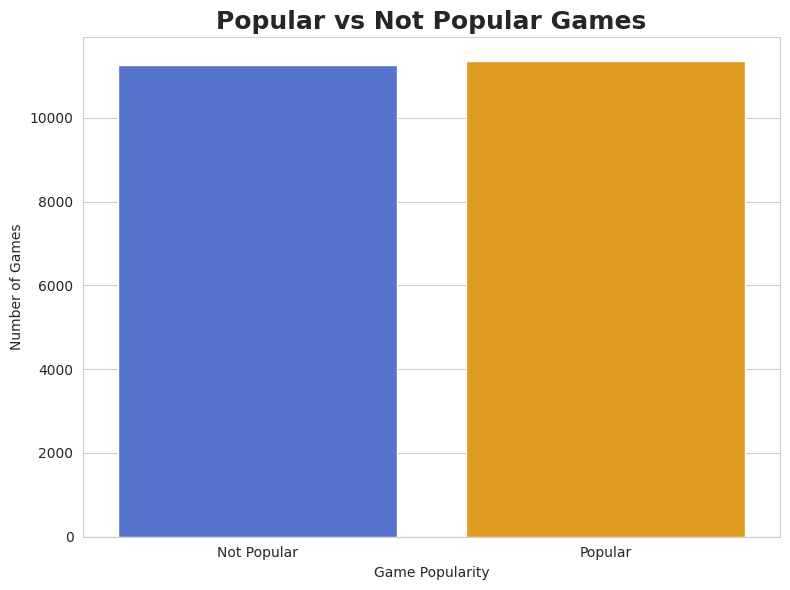

In [47]:
plt.figure(figsize=(8, 6))

sns.countplot(
    data=df_ml,
    x="popular_game",
    palette=["royalblue", "orange"]
)

plt.title(
    "Popular vs Not Popular Games",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Game Popularity")
plt.ylabel("Number of Games")

plt.xticks(
    [0, 1],
    ["Not Popular", "Popular"]
)

plt.tight_layout()
plt.show()

In [48]:
features = [
    # Extended Steam
    "appid",
    "positive",
    "negative",
    "average_forever",
    "average_2weeks",
    "median_forever",
    "median_2weeks",
    "price",
    "initialprice",
    "discount",
    "required_age",
    "metacritic_score",
    "recommendations",
    "achievements",

    # Categorical
    "developer",
    "publisher",
    "owners",
    "is_free",
    "platforms_windows",
    "platforms_mac",
    "platforms_linux",

    # Wikidata
    "hltb_id",
    "metacritic_id",
    "opencritic_id",
    "esrb_rating",
    "igdb_id",
    "game_engine"
]


# Keep only columns that exist
features = [
    col for col in features
    if col in df_ml.columns
]

print("Selected Features:")
print(features)

print("\nNumber of Features:", len(features))

Selected Features:
['appid', 'positive', 'negative', 'average_forever', 'average_2weeks', 'median_forever', 'median_2weeks', 'price', 'initialprice', 'discount', 'required_age', 'metacritic_score', 'recommendations', 'achievements', 'developer', 'publisher', 'owners', 'is_free', 'platforms_windows', 'platforms_mac', 'platforms_linux', 'hltb_id', 'metacritic_id', 'opencritic_id', 'esrb_rating', 'igdb_id', 'game_engine']

Number of Features: 27


In [49]:
X = df_ml[features].copy()

y = df_ml["popular_game"].copy()

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (22608, 27)
y Shape: (22608,)


In [50]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()


print("\nNumerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)


Numerical Features:
['appid', 'positive', 'negative', 'average_forever', 'average_2weeks', 'median_forever', 'median_2weeks', 'price', 'initialprice', 'discount', 'required_age', 'metacritic_score', 'recommendations', 'achievements', 'hltb_id', 'metacritic_id', 'opencritic_id']

Categorical Features:
['developer', 'publisher', 'owners', 'is_free', 'platforms_windows', 'platforms_mac', 'platforms_linux', 'esrb_rating', 'igdb_id', 'game_engine']


In [51]:
label_encoders = {}

for col in categorical_features:

    # Convert missing values
    X[col] = X[col].fillna("Unknown").astype(str)

    encoder = LabelEncoder()

    X[col] = encoder.fit_transform(
        X[col]
    )

    label_encoders[col] = encoder

    print(
        f"{col:<25} -> "
        f"{len(encoder.classes_)} categories encoded"
    )

developer                 -> 15156 categories encoded
publisher                 -> 12061 categories encoded
owners                    -> 12 categories encoded
is_free                   -> 3 categories encoded
platforms_windows         -> 3 categories encoded
platforms_mac             -> 3 categories encoded
platforms_linux           -> 3 categories encoded
esrb_rating               -> 13 categories encoded
igdb_id                   -> 20866 categories encoded
game_engine               -> 305 categories encoded


In [52]:
for col, encoder in label_encoders.items():

    print("\nColumn:", col)

    mapping = dict(
        zip(
            encoder.classes_[:10],
            range(
                min(10, len(encoder.classes_))
            )
        )
    )

    print(mapping)


Column: developer
{' PotionWorks': 0, '!CyberApex (SkagoGames)': 1, '#workshop': 2, '+7 Software': 3, '+Mpact Games, LLC.': 4, '+Umbrella': 5, '.GRAVITY': 6, '//commentout': 7, '0 Deer Soft': 8, '007berd': 9}

Column: publisher
{' ': 0, '  Milestone S.r.l.': 1, ' 505 Games': 2, ' 6 Toad Games': 3, ' Aigi Studios': 4, ' Alternative Reality Games 2015': 5, ' Appnori Inc.': 6, ' Asset Flip Studio': 7, ' Asterion Games': 8, ' Attack Studio': 9}

Column: owners
{'1,000,000 .. 2,000,000': 0, '10,000,000 .. 20,000,000': 1, '100,000 .. 200,000': 2, '100,000,000 .. 200,000,000': 3, '2,000,000 .. 5,000,000': 4, '20,000 .. 50,000': 5, '20,000,000 .. 50,000,000': 6, '200,000 .. 500,000': 7, '5,000,000 .. 10,000,000': 8, '50,000 .. 100,000': 9}

Column: is_free
{'False': 0, 'True': 1, 'Unknown': 2}

Column: platforms_windows
{'False': 0, 'True': 1, 'Unknown': 2}

Column: platforms_mac
{'False': 0, 'True': 1, 'Unknown': 2}

Column: platforms_linux
{'False': 0, 'True': 1, 'Unknown': 2}

Column: esrb

In [53]:
for col in X.columns:

    X[col] = pd.to_numeric(
        X[col],
        errors="coerce"
    )


print(
    "Remaining object columns:",
    X.select_dtypes(include="object").columns.tolist()
)

Remaining object columns: []


In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("=" * 60)
print("TRAIN TEST SPLIT")
print("=" * 60)

print("X Train:", X_train.shape)
print("X Test :", X_test.shape)

print("y Train:", y_train.shape)
print("y Test :", y_test.shape)

TRAIN TEST SPLIT
X Train: (18086, 27)
X Test : (4522, 27)
y Train: (18086,)
y Test : (4522,)


In [55]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("Scaling completed successfully.")

Scaling completed successfully.


STARTING STEAM GAMES MACHINE LEARNING
df_ml shape: (22608, 50)

Selected Features:
['appid', 'positive', 'negative', 'average_forever', 'average_2weeks', 'median_forever', 'median_2weeks', 'price', 'initialprice', 'discount', 'required_age', 'metacritic_score', 'recommendations', 'achievements', 'developer', 'publisher', 'owners', 'is_free', 'platforms_windows', 'platforms_mac', 'platforms_linux', 'hltb_id', 'metacritic_id', 'opencritic_id', 'esrb_rating', 'igdb_id', 'game_engine']

Number of features: 27

X shape: (22608, 27)
y shape: (22608,)

Categorical Columns:
['developer', 'publisher', 'owners', 'is_free', 'platforms_windows', 'platforms_mac', 'platforms_linux', 'esrb_rating', 'igdb_id', 'game_engine']

Numerical Columns:
['appid', 'positive', 'negative', 'average_forever', 'average_2weeks', 'median_forever', 'median_2weeks', 'price', 'initialprice', 'discount', 'required_age', 'metacritic_score', 'recommendations', 'achievements', 'hltb_id', 'metacritic_id', 'opencritic_id']
En

metacritic_id       22608
hltb_id             22607
metacritic_score    18936
opencritic_id       16481
required_age           45
recommendations        45
achievements           45
dtype: int64


Completely Empty Columns:
['metacritic_id']

X shape after empty-column removal: (22608, 26)

TRAIN TEST SPLIT
X_train: (18086, 26)
X_test : (4522, 26)
y_train: (18086,)
y_test : (4522,)

DATA VALIDATION BEFORE SCALING
Train NaN: 0
Test NaN: 0
Train Inf: 0
Test Inf: 0

FINAL MODEL INPUT
X_train_scaled shape: (18086, 26)
X_test_scaled shape: (4522, 26)
NaN in train: 0
NaN in test: 0
Inf in train: 0
Inf in test: 0

✓ DATA IS CLEAN
✓ NO NaN
✓ NO INFINITY
✓ READY FOR MACHINE LEARNING


Logistic Regression
Accuracy  : 77.18%
Precision : 84.21%
Recall    : 67.15%
F1 Score  : 74.72%


Decision Tree
Accuracy  : 81.67%
Precision : 84.33%
Recall    : 77.98%
F1 Score  : 81.03%


Random Forest
Accuracy  : 83.66%
Precision : 85.23%
Recall    : 81.59%
F1 Score  : 83.37%


Extra Trees
Accuracy  : 78.33%
Precision : 83.85%
Recall    : 70.41%
F1 Score  : 76.54%


KNN
Accuracy  : 71.03%
Precision : 73.94%
Recall    : 65.35%
F1 Score  : 69.38%


SVM
Accuracy  : 73.97%
Precision : 78.05%
Recall    : 67.0

,Algorithm,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,Gradient Boosting,83.75%,85.56%,81.37%,83.41%
1,Random Forest,83.66%,85.23%,81.59%,83.37%
2,Decision Tree,81.67%,84.33%,77.98%,81.03%
3,Extra Trees,78.33%,83.85%,70.41%,76.54%
4,Logistic Regression,77.18%,84.21%,67.15%,74.72%
5,SVM,73.97%,78.05%,67.02%,72.12%
6,KNN,71.03%,73.94%,65.35%,69.38%


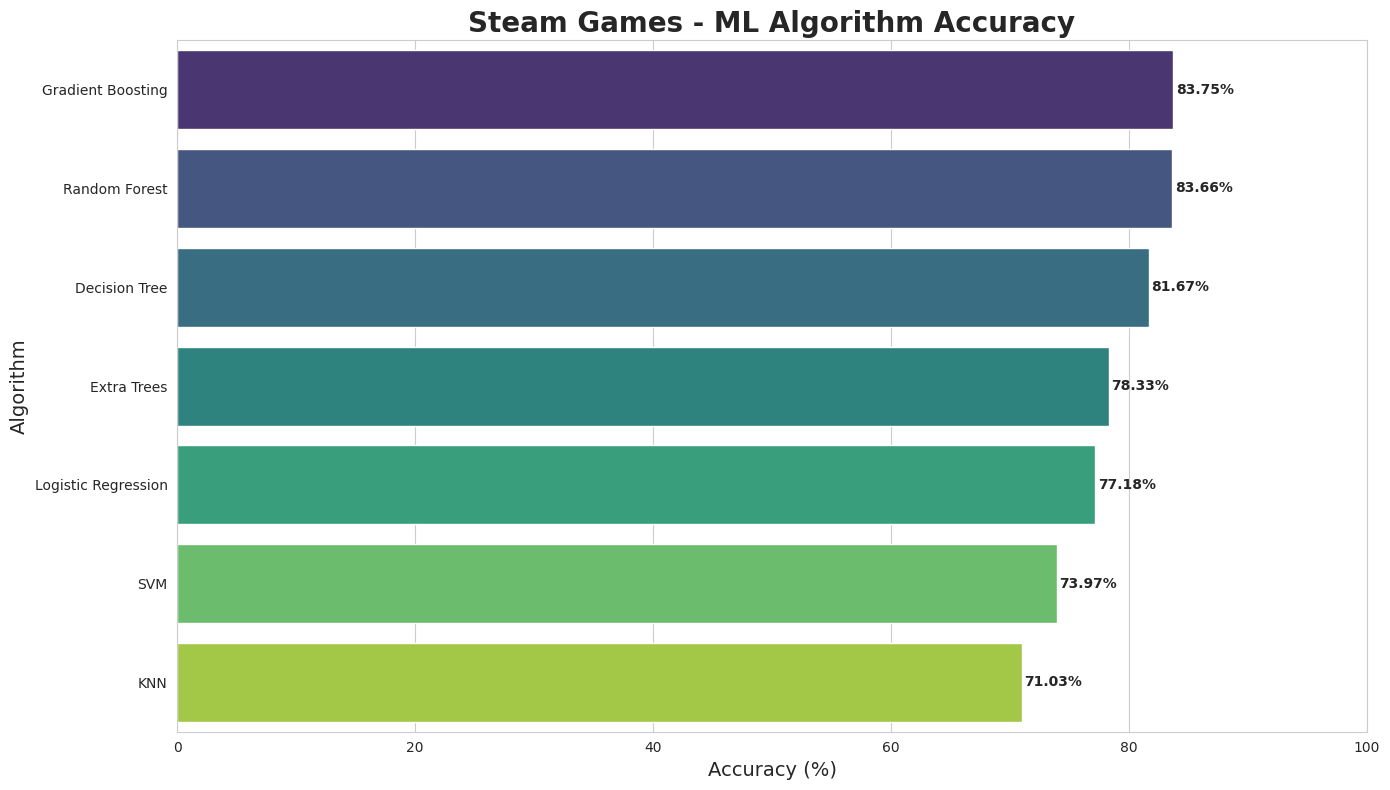



BEST MODEL
Algorithm: Gradient Boosting
Accuracy: 83.75%


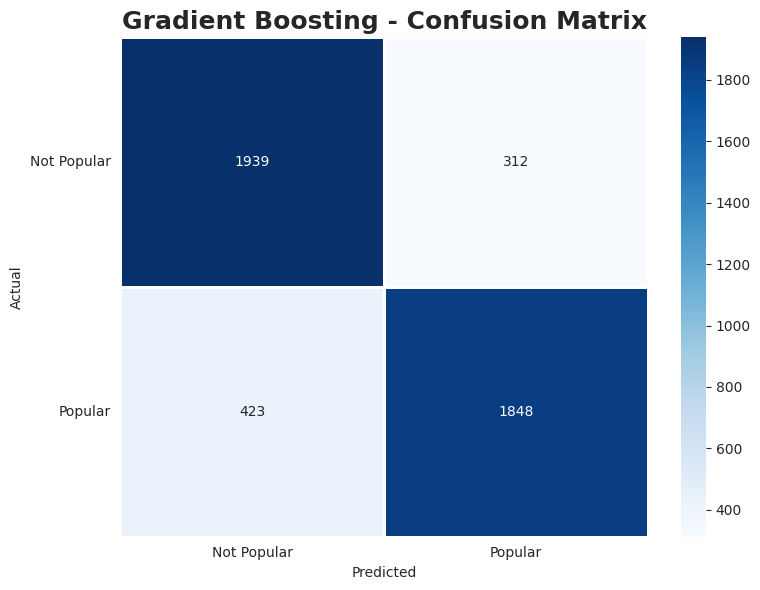



CLASSIFICATION REPORT
              precision    recall  f1-score   support

 Not Popular       0.82      0.86      0.84      2251
     Popular       0.86      0.81      0.83      2271

    accuracy                           0.84      4522
   macro avg       0.84      0.84      0.84      4522
weighted avg       0.84      0.84      0.84      4522



In [56]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")


# ============================================================
# 1. START FROM df_ml
# ============================================================

print("=" * 80)
print("STARTING STEAM GAMES MACHINE LEARNING")
print("=" * 80)

print("df_ml shape:", df_ml.shape)


# ============================================================
# 2. SELECT FEATURES
# ============================================================

features = [

    # Extended Steam Games
    "appid",
    "positive",
    "negative",
    "average_forever",
    "average_2weeks",
    "median_forever",
    "median_2weeks",
    "price",
    "initialprice",
    "discount",
    "required_age",
    "metacritic_score",
    "recommendations",
    "achievements",

    # Categorical
    "developer",
    "publisher",
    "owners",
    "is_free",
    "platforms_windows",
    "platforms_mac",
    "platforms_linux",

    # Wikidata
    "hltb_id",
    "metacritic_id",
    "opencritic_id",
    "esrb_rating",
    "igdb_id",
    "game_engine"
]


# Keep only columns that actually exist
features = [
    col for col in features
    if col in df_ml.columns
]


print("\nSelected Features:")
print(features)

print("\nNumber of features:", len(features))


# ============================================================
# 3. CREATE X AND y
# ============================================================

X = df_ml[features].copy()

y = df_ml["popular_game"].copy()


print("\nX shape:", X.shape)
print("y shape:", y.shape)


# ============================================================
# 4. REMOVE INFINITE VALUES
# ============================================================

# Replace infinity with NaN
X = X.replace(
    [np.inf, -np.inf],
    np.nan
)


# ============================================================
# 5. IDENTIFY CATEGORICAL COLUMNS
# ============================================================

categorical_columns = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()


numerical_columns = X.select_dtypes(
    exclude=["object", "string", "category"]
).columns.tolist()


print("\nCategorical Columns:")
print(categorical_columns)

print("\nNumerical Columns:")
print(numerical_columns)


# ============================================================
# 6. LABEL ENCODING
# ============================================================

label_encoders = {}


for col in categorical_columns:

    # Convert missing values to string
    X[col] = X[col].fillna(
        "Unknown"
    )

    X[col] = X[col].astype(str)

    # Create encoder
    encoder = LabelEncoder()

    # Encode
    X[col] = encoder.fit_transform(
        X[col]
    )

    # Save encoder
    label_encoders[col] = encoder


    print(
        f"Encoded: {col:<25} "
        f"Categories: {len(encoder.classes_)}"
    )


# ============================================================
# 7. CONVERT EVERYTHING TO NUMERIC
# ============================================================

for col in X.columns:

    X[col] = pd.to_numeric(
        X[col],
        errors="coerce"
    )


# ============================================================
# 8. REPLACE INF AGAIN
# ============================================================

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)


# ============================================================
# 9. SHOW MISSING VALUES
# ============================================================

missing = (
    X.isna()
     .sum()
     .sort_values(ascending=False)
)

print("\nMissing Values:")
display(
    missing[missing > 0]
)


# ============================================================
# 10. REMOVE COMPLETELY EMPTY COLUMNS
# ============================================================

completely_empty = X.columns[
    X.isna().all()
].tolist()


print("\nCompletely Empty Columns:")
print(completely_empty)


if len(completely_empty) > 0:

    X = X.drop(
        columns=completely_empty
    )


print(
    "\nX shape after empty-column removal:",
    X.shape
)


# ============================================================
# 11. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)


print("\n" + "=" * 80)
print("TRAIN TEST SPLIT")
print("=" * 80)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


# ============================================================
# 12. IMPUTATION
# ============================================================

imputer = SimpleImputer(
    strategy="median"
)


# FIT ONLY TRAINING DATA
X_train_array = imputer.fit_transform(
    X_train
)


# TRANSFORM TEST DATA
X_test_array = imputer.transform(
    X_test
)


# ============================================================
# 13. CONVERT TO DATAFRAME
# ============================================================

X_train = pd.DataFrame(
    X_train_array,
    columns=X_train.columns,
    index=X_train.index
)


X_test = pd.DataFrame(
    X_test_array,
    columns=X_test.columns,
    index=X_test.index
)


# ============================================================
# 14. FORCE FINAL NaN CLEANING
# ============================================================

# Training medians
train_medians = X_train.median()


# Fill any remaining NaN
X_train = X_train.fillna(
    train_medians
)


X_test = X_test.fillna(
    train_medians
)


# Replace infinity again
X_train = X_train.replace(
    [np.inf, -np.inf],
    np.nan
)

X_test = X_test.replace(
    [np.inf, -np.inf],
    np.nan
)


# Fill again
X_train = X_train.fillna(
    train_medians
)

X_test = X_test.fillna(
    train_medians
)


# ============================================================
# 15. FINAL DATA VALIDATION
# ============================================================

print("\n" + "=" * 80)
print("DATA VALIDATION BEFORE SCALING")
print("=" * 80)

print(
    "Train NaN:",
    X_train.isna().sum().sum()
)

print(
    "Test NaN:",
    X_test.isna().sum().sum()
)

print(
    "Train Inf:",
    np.isinf(X_train.to_numpy()).sum()
)

print(
    "Test Inf:",
    np.isinf(X_test.to_numpy()).sum()
)


# ============================================================
# 16. STANDARD SCALING
# ============================================================

scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(
    X_train
)


X_test_scaled = scaler.transform(
    X_test
)


# ============================================================
# 17. FINAL MODEL INPUT VALIDATION
# ============================================================

print("\n" + "=" * 80)
print("FINAL MODEL INPUT")
print("=" * 80)

print(
    "X_train_scaled shape:",
    X_train_scaled.shape
)

print(
    "X_test_scaled shape:",
    X_test_scaled.shape
)

print(
    "NaN in train:",
    np.isnan(X_train_scaled).sum()
)

print(
    "NaN in test:",
    np.isnan(X_test_scaled).sum()
)

print(
    "Inf in train:",
    np.isinf(X_train_scaled).sum()
)

print(
    "Inf in test:",
    np.isinf(X_test_scaled).sum()
)


# ============================================================
# 18. STOP IF NaN STILL EXISTS
# ============================================================

if np.isnan(X_train_scaled).any():

    raise ValueError(
        "NaN still exists in X_train_scaled"
    )


if np.isnan(X_test_scaled).any():

    raise ValueError(
        "NaN still exists in X_test_scaled"
    )


if np.isinf(X_train_scaled).any():

    raise ValueError(
        "Infinity still exists in X_train_scaled"
    )


if np.isinf(X_test_scaled).any():

    raise ValueError(
        "Infinity still exists in X_test_scaled"
    )


print(
    "\n✓ DATA IS CLEAN"
)

print(
    "✓ NO NaN"
)

print(
    "✓ NO INFINITY"
)

print(
    "✓ READY FOR MACHINE LEARNING"
)


# ============================================================
# 19. DEFINE MODELS
# ============================================================

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            random_state=42
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            max_depth=10,
            min_samples_split=10,
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            max_depth=15,
            min_samples_split=5,
            random_state=42,
            n_jobs=-1
        ),

    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=200,
            max_depth=15,
            random_state=42,
            n_jobs=-1
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=5
        ),

    "SVM":
        SVC(
            kernel="rbf",
            C=1.0,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=5,
            random_state=42
        )
}


# ============================================================
# 20. TRAIN ALL MODELS
# ============================================================

results = []

predictions = {}


for name, model in models.items():

    print("\n")
    print("=" * 70)
    print(name)
    print("=" * 70)


    # Scaled models
    if name in [
        "Logistic Regression",
        "KNN",
        "SVM"
    ]:

        model.fit(
            X_train_scaled,
            y_train
        )

        prediction = model.predict(
            X_test_scaled
        )


    # Tree models
    else:

        model.fit(
            X_train,
            y_train
        )

        prediction = model.predict(
            X_test
        )


    # Metrics
    accuracy = accuracy_score(
        y_test,
        prediction
    )

    precision = precision_score(
        y_test,
        prediction,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        prediction,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        prediction,
        zero_division=0
    )


    results.append({

        "Algorithm": name,

        "Accuracy (%)":
            accuracy * 100,

        "Precision (%)":
            precision * 100,

        "Recall (%)":
            recall * 100,

        "F1 Score (%)":
            f1 * 100
    })


    predictions[name] = prediction


    print(
        f"Accuracy  : {accuracy * 100:.2f}%"
    )

    print(
        f"Precision : {precision * 100:.2f}%"
    )

    print(
        f"Recall    : {recall * 100:.2f}%"
    )

    print(
        f"F1 Score  : {f1 * 100:.2f}%"
    )


# ============================================================
# 21. RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(
    results
)


results_df = results_df.sort_values(
    by="Accuracy (%)",
    ascending=False
).reset_index(drop=True)


print("\n")
print("=" * 80)
print("FINAL MODEL RESULTS")
print("=" * 80)


display(
    results_df.style.format({

        "Accuracy (%)": "{:.2f}%",

        "Precision (%)": "{:.2f}%",

        "Recall (%)": "{:.2f}%",

        "F1 Score (%)": "{:.2f}%"

    })
)


# ============================================================
# 22. ACCURACY GRAPH
# ============================================================

plt.figure(
    figsize=(14, 8)
)


sns.barplot(
    data=results_df,
    x="Accuracy (%)",
    y="Algorithm",
    palette="viridis"
)


plt.title(
    "Steam Games - ML Algorithm Accuracy",
    fontsize=20,
    fontweight="bold"
)


plt.xlabel(
    "Accuracy (%)",
    fontsize=14
)


plt.ylabel(
    "Algorithm",
    fontsize=14
)


for i, value in enumerate(
    results_df["Accuracy (%)"]
):

    plt.text(
        value + 0.2,
        i,
        f"{value:.2f}%",
        va="center",
        fontweight="bold"
    )


plt.xlim(
    0,
    100
)


plt.tight_layout()

plt.show()


# ============================================================
# 23. BEST MODEL
# ============================================================

best_name = results_df.iloc[0][
    "Algorithm"
]

best_accuracy = results_df.iloc[0][
    "Accuracy (%)"
]

best_prediction = predictions[
    best_name
]


print("\n")
print("=" * 80)
print("BEST MODEL")
print("=" * 80)

print(
    "Algorithm:",
    best_name
)

print(
    f"Accuracy: {best_accuracy:.2f}%"
)


# ============================================================
# 24. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    best_prediction
)


plt.figure(
    figsize=(8, 6)
)


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=1
)


plt.title(
    f"{best_name} - Confusion Matrix",
    fontsize=18,
    fontweight="bold"
)


plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)


plt.xticks(
    [0.5, 1.5],
    ["Not Popular", "Popular"]
)


plt.yticks(
    [0.5, 1.5],
    ["Not Popular", "Popular"],
    rotation=0
)


plt.tight_layout()

plt.show()


# ============================================================
# 25. CLASSIFICATION REPORT
# ============================================================

print("\n")
print("=" * 80)
print("CLASSIFICATION REPORT")
print("=" * 80)

print(
    classification_report(
        y_test,
        best_prediction,
        target_names=[
            "Not Popular",
            "Popular"
        ],
        zero_division=0
    )
)

In [57]:
results_df = pd.DataFrame(
    results
)

results_df = results_df.sort_values(
    by="Accuracy (%)",
    ascending=False
).reset_index(drop=True)


print("=" * 80)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 80)

display(
    results_df.style.format({
        "Accuracy (%)": "{:.2f}%",
        "Precision (%)": "{:.2f}%",
        "Recall (%)": "{:.2f}%",
        "F1 Score (%)": "{:.2f}%"
    })
)

MODEL PERFORMANCE COMPARISON


,Algorithm,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,Gradient Boosting,83.75%,85.56%,81.37%,83.41%
1,Random Forest,83.66%,85.23%,81.59%,83.37%
2,Decision Tree,81.67%,84.33%,77.98%,81.03%
3,Extra Trees,78.33%,83.85%,70.41%,76.54%
4,Logistic Regression,77.18%,84.21%,67.15%,74.72%
5,SVM,73.97%,78.05%,67.02%,72.12%
6,KNN,71.03%,73.94%,65.35%,69.38%


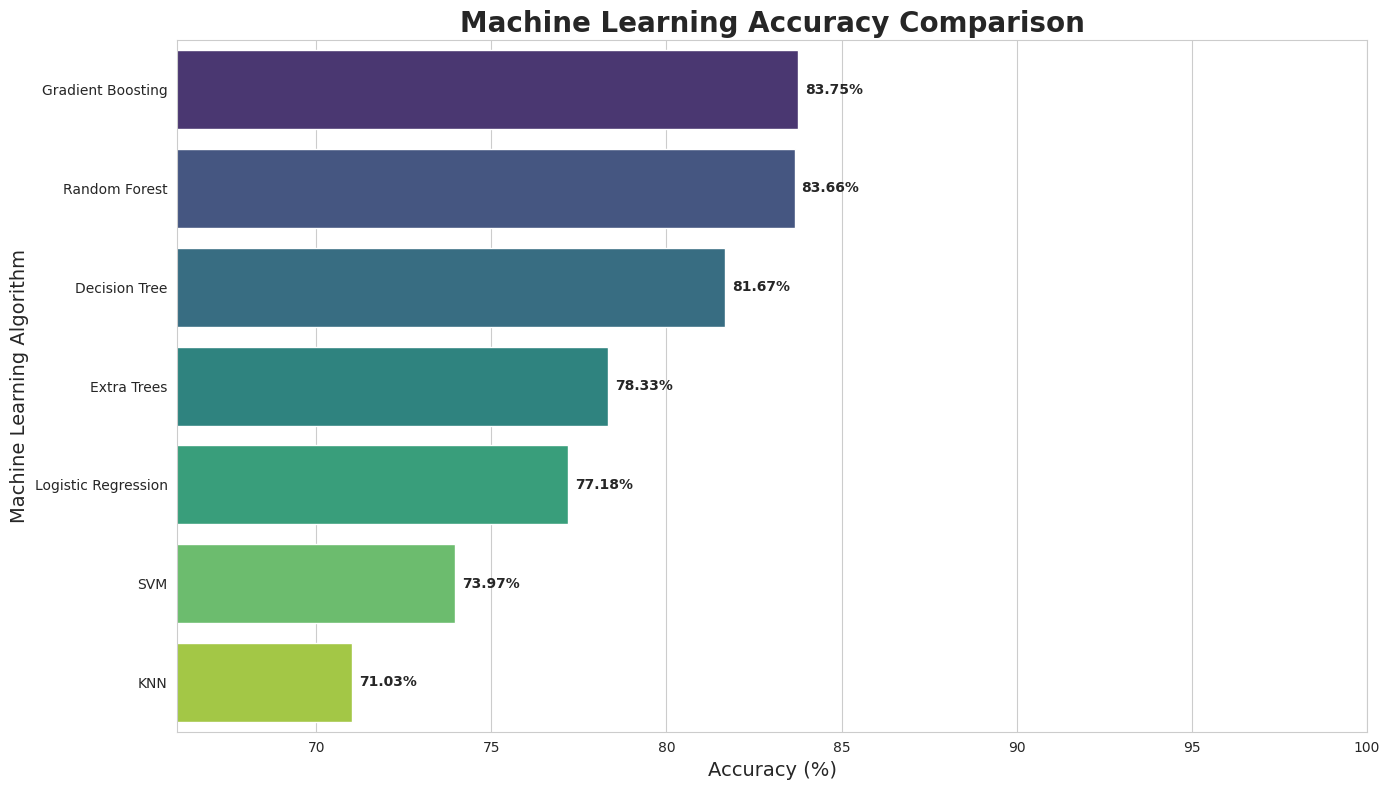

In [58]:
plt.figure(figsize=(14, 8))

sns.barplot(
    data=results_df,
    x="Accuracy (%)",
    y="Algorithm",
    palette="viridis"
)

plt.title(
    "Machine Learning Accuracy Comparison",
    fontsize=20,
    fontweight="bold"
)

plt.xlabel(
    "Accuracy (%)",
    fontsize=14
)

plt.ylabel(
    "Machine Learning Algorithm",
    fontsize=14
)

# Add percentage labels
for i, value in enumerate(
    results_df["Accuracy (%)"]
):

    plt.text(
        value + 0.2,
        i,
        f"{value:.2f}%",
        va="center",
        fontweight="bold"
    )

plt.xlim(
    max(
        0,
        results_df["Accuracy (%)"].min() - 5
    ),
    100
)

plt.tight_layout()
plt.show()

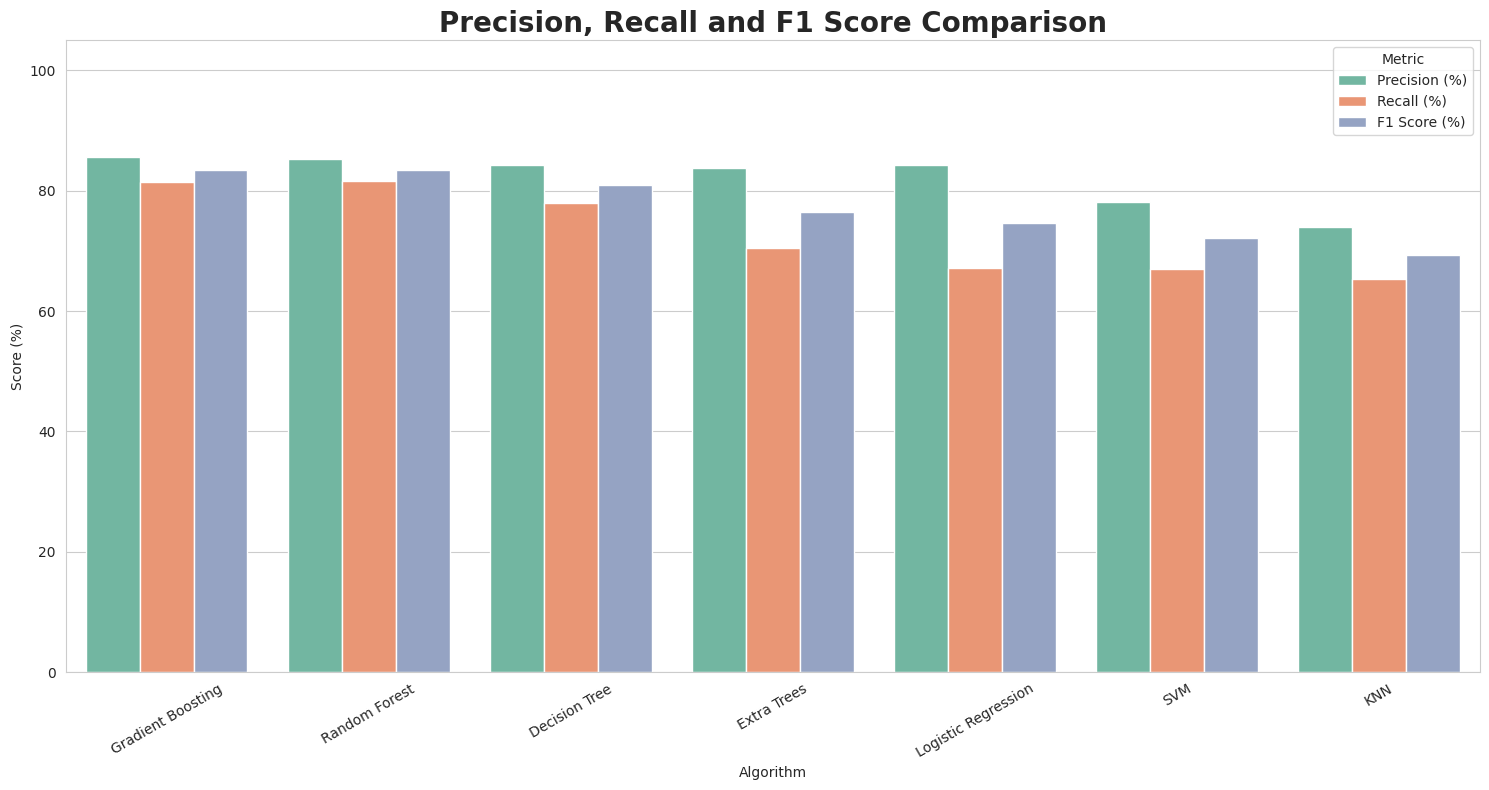

In [59]:
metrics_df = results_df[
    [
        "Algorithm",
        "Precision (%)",
        "Recall (%)",
        "F1 Score (%)"
    ]
]

metrics_long = metrics_df.melt(
    id_vars="Algorithm",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(15, 8))

sns.barplot(
    data=metrics_long,
    x="Algorithm",
    y="Score",
    hue="Metric",
    palette="Set2"
)

plt.title(
    "Precision, Recall and F1 Score Comparison",
    fontsize=20,
    fontweight="bold"
)

plt.xlabel("Algorithm")
plt.ylabel("Score (%)")

plt.xticks(rotation=30)

plt.ylim(0, 105)

plt.tight_layout()
plt.show()

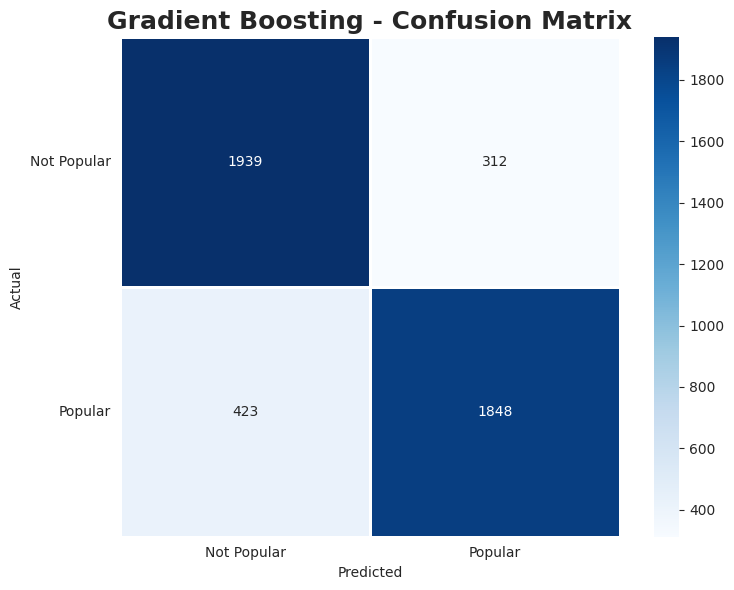

In [60]:
best_model_name = results_df.iloc[0]["Algorithm"]

best_predictions = predictions[
    best_model_name
]

cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=1,
    square=True
)

plt.title(
    f"{best_model_name} - Confusion Matrix",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0.5, 1.5],
    ["Not Popular", "Popular"]
)

plt.yticks(
    [0.5, 1.5],
    ["Not Popular", "Popular"],
    rotation=0
)

plt.tight_layout()
plt.show()

In [61]:
print("=" * 70)
print("BEST MODEL")
print("=" * 70)

print(
    "Algorithm:",
    best_model_name
)

print(
    "Accuracy:",
    f"{results_df.iloc[0]['Accuracy (%)']:.2f}%"
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        best_predictions,
        target_names=[
            "Not Popular",
            "Popular"
        ],
        zero_division=0
    )
)

BEST MODEL
Algorithm: Gradient Boosting
Accuracy: 83.75%

Classification Report:

              precision    recall  f1-score   support

 Not Popular       0.82      0.86      0.84      2251
     Popular       0.86      0.81      0.83      2271

    accuracy                           0.84      4522
   macro avg       0.84      0.84      0.84      4522
weighted avg       0.84      0.84      0.84      4522



In [62]:
try:

    from xgboost import XGBClassifier

    xgb_model = XGBClassifier(
        n_estimators=250,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    xgb_model.fit(
        X_train,
        y_train
    )

    y_pred_xgb = xgb_model.predict(
        X_test
    )

    xgb_accuracy = accuracy_score(
        y_test,
        y_pred_xgb
    )

    xgb_precision = precision_score(
        y_test,
        y_pred_xgb,
        zero_division=0
    )

    xgb_recall = recall_score(
        y_test,
        y_pred_xgb,
        zero_division=0
    )

    xgb_f1 = f1_score(
        y_test,
        y_pred_xgb,
        zero_division=0
    )

    print("=" * 70)
    print("XGBOOST RESULTS")
    print("=" * 70)

    print(
        f"Accuracy  : {xgb_accuracy * 100:.2f}%"
    )

    print(
        f"Precision : {xgb_precision * 100:.2f}%"
    )

    print(
        f"Recall    : {xgb_recall * 100:.2f}%"
    )

    print(
        f"F1 Score  : {xgb_f1 * 100:.2f}%"
    )

except Exception as e:

    print("XGBoost could not be trained.")
    print("Error:", e)

XGBOOST RESULTS
Accuracy  : 83.72%
Precision : 85.32%
Recall    : 81.64%
F1 Score  : 83.44%


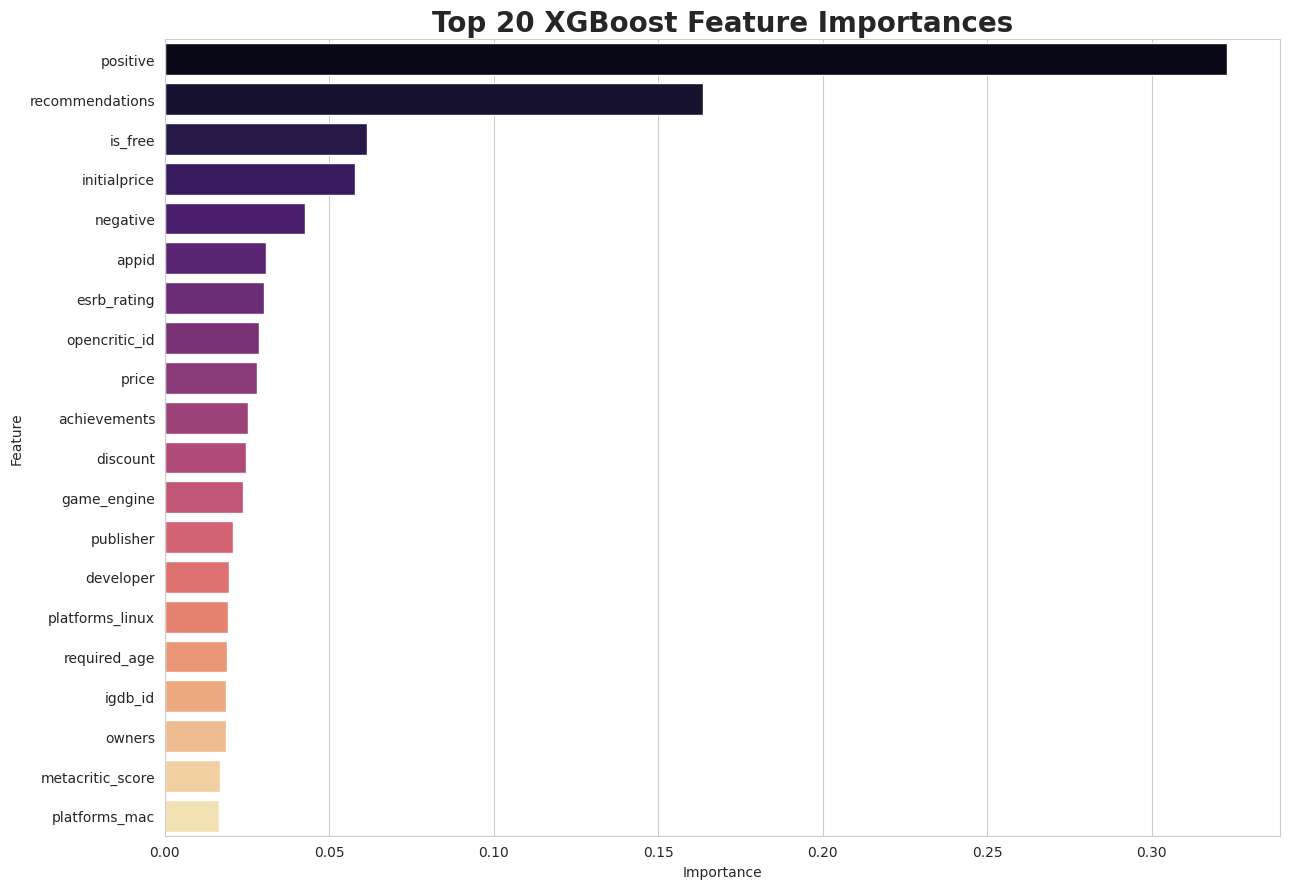

,Feature,Importance
1,positive,0.322854
12,recommendations,0.163466
17,is_free,0.061397
8,initialprice,0.057817
2,negative,0.042549
0,appid,0.030719
23,esrb_rating,0.030055
22,opencritic_id,0.028580
7,price,0.027964
13,achievements,0.025352


In [63]:
if "xgb_model" in locals():

    xgb_importance = pd.DataFrame({

        "Feature": X.columns,

        "Importance":
            xgb_model.feature_importances_
    })

    xgb_importance = (
        xgb_importance
        .sort_values(
            "Importance",
            ascending=False
        )
        .head(20)
    )


    plt.figure(figsize=(13, 9))

    sns.barplot(
        data=xgb_importance,
        x="Importance",
        y="Feature",
        palette="magma"
    )

    plt.title(
        "Top 20 XGBoost Feature Importances",
        fontsize=20,
        fontweight="bold"
    )

    plt.xlabel("Importance")
    plt.ylabel("Feature")

    plt.tight_layout()
    plt.show()

    display(xgb_importance)

,Feature,Importance
1,positive,0.262417
12,recommendations,0.220603
2,negative,0.124175
8,initialprice,0.060461
0,appid,0.051455
7,price,0.040427
13,achievements,0.039518
15,publisher,0.031898
14,developer,0.031433
24,igdb_id,0.030633


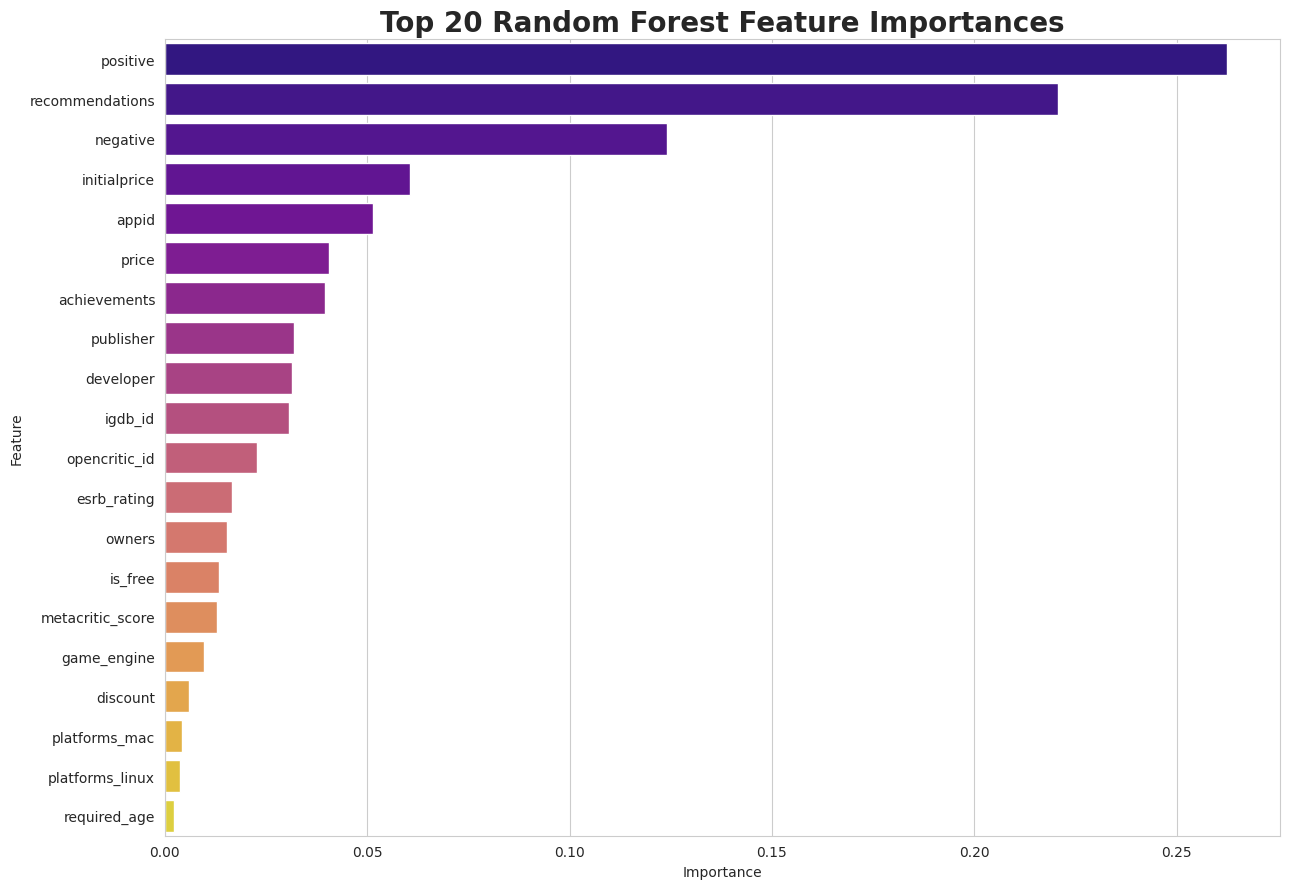

In [64]:
rf_model = models["Random Forest"]

rf_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance":
        rf_model.feature_importances_
})

rf_importance = (
    rf_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)


display(
    rf_importance.head(20)
)


plt.figure(figsize=(13, 9))

sns.barplot(
    data=rf_importance.head(20),
    x="Importance",
    y="Feature",
    palette="plasma"
)

plt.title(
    "Top 20 Random Forest Feature Importances",
    fontsize=20,
    fontweight="bold"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [65]:
print("\n")
print("=" * 80)
print("EXTENDED STEAM GAMES - MACHINE LEARNING SUMMARY")
print("=" * 80)

print(
    f"Total Dataset Rows : {df.shape[0]:,}"
)

print(
    f"Total Dataset Columns : {df.shape[1]:,}"
)

print(
    f"ML Rows : {X.shape[0]:,}"
)

print(
    f"ML Features : {X.shape[1]:,}"
)

print(
    f"Training Samples : {X_train.shape[0]:,}"
)

print(
    f"Testing Samples : {X_test.shape[0]:,}"
)

print(
    f"Median CCU : {ccu_median:,.0f}"
)

print("\n" + "-" * 80)

print("MODEL ACCURACIES")

print("-" * 80)

for _, row in results_df.iterrows():

    print(
        f"{row['Algorithm']:<25} "
        f"{row['Accuracy (%)']:.2f}%"
    )

if "xgb_accuracy" in locals():

    print(
        f"{'XGBoost':<25} "
        f"{xgb_accuracy * 100:.2f}%"
    )


print("-" * 80)

print(
    f"BEST MODEL : {best_model_name}"
)

print(
    f"BEST ACCURACY : "
    f"{results_df.iloc[0]['Accuracy (%)']:.2f}%"
)

print("=" * 80)



EXTENDED STEAM GAMES - MACHINE LEARNING SUMMARY
Total Dataset Rows : 22,608
Total Dataset Columns : 49
ML Rows : 22,608
ML Features : 26
Training Samples : 18,086
Testing Samples : 4,522
Median CCU : 1

--------------------------------------------------------------------------------
MODEL ACCURACIES
--------------------------------------------------------------------------------
Gradient Boosting         83.75%
Random Forest             83.66%
Decision Tree             81.67%
Extra Trees               78.33%
Logistic Regression       77.18%
SVM                       73.97%
KNN                       71.03%
XGBoost                   83.72%
--------------------------------------------------------------------------------
BEST MODEL : Gradient Boosting
BEST ACCURACY : 83.75%


## Thank you..pls upvote!!!!!